# **Análisis exploratorio inicial y PCA**
Esthefania Ortega

## **0. Carga de librerías y dependencias**

In [505]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
from scipy import stats #Para detección de outliers

#PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

#Estilo de gráficas
plt.style.use('ggplot')

## **1. Carga de datos**

In [506]:
rick = pd.read_csv('../data/interim/rick_hist.csv')
print(f'Tamaño del dataset: {rick.shape}')
rick.head()

Tamaño del dataset: (2631, 173)


,ide_id,ide_sex,ide_eda_ano,des_cal,ide_col,des_jur_res,des_mpo_res,cve_loc_res,des_loc_res,ide_cp,...,ricket_cq,res_final_ricket_inmuno,res_final_ricket_rtpcr,fecha_resultado_rickett_rtpcr,ricket_especie_rtpcr,tratamiento_rickettsiosis,fec_ini_trat_ricket,fec_fin_trat_ricket,med_trat_ricket,des_ins_uni_trat_norm
0,928424,1,39,CALLE,PASEOS DEL PEDREGAL Fraccionamiento,HERMOSILLO,HERMOSILLO,289,HERMOSILLO,83118.00,...,0.00,0.00,1.00,2022-01-05,0.00,1,2022-01-01,2022-01-04,1,SSA
1,928745,2,8,CALLE,SAN RAFAEL Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83557.00,...,0.00,0.00,2.00,2022-01-13,0.00,1,2022-01-05,NaN,1,NaN
2,928768,2,2,CALLE,EL BOSQUE (CALLE QUINCE) Ejido,CAJEME,CAJEME,365,QUETCHEHUECA,85207.00,...,NaN,NaN,NaN,NaN,NaN,1,2022-01-06,NaN,0,SSA
3,929029,1,9,PRIVADA,PUERTO PEÑASCO CENTRO Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83550.00,...,0.00,0.00,2.00,2022-01-13,0.00,1,2022-01-10,NaN,1,NaN
4,929184,2,13,CALLE,PALO BLANCO Congregación,NAVOJOA,NAVOJOA,124,TESIA,85235.00,...,0.00,1.00,1.00,NaN,0.00,1,2022-01-14,NaN,1,IMSS Ordinario


## **2. Análisis general del dataset**

### 2.1 **Tamaño y variables**

In [507]:
print(rick.info())
rick.columns

<class 'pandas.DataFrame'>
RangeIndex: 2631 entries, 0 to 2630
Columns: 173 entries, ide_id to des_ins_uni_trat_norm
dtypes: float64(9), int64(126), str(38)
memory usage: 3.5 MB
None


Index(['ide_id', 'ide_sex', 'ide_eda_ano', 'des_cal', 'ide_col', 'des_jur_res',
       'des_mpo_res', 'cve_loc_res', 'des_loc_res', 'ide_cp',
       ...
       'ricket_cq', 'res_final_ricket_inmuno', 'res_final_ricket_rtpcr',
       'fecha_resultado_rickett_rtpcr', 'ricket_especie_rtpcr',
       'tratamiento_rickettsiosis', 'fec_ini_trat_ricket',
       'fec_fin_trat_ricket', 'med_trat_ricket', 'des_ins_uni_trat_norm'],
      dtype='str', length=173)

In [508]:
print('Tipos de datos:')
rick.dtypes

Tipos de datos:


ide_id                       int64
ide_sex                      int64
ide_eda_ano                  int64
des_cal                        str
ide_col                        str
                             ...  
tratamiento_rickettsiosis    int64
fec_ini_trat_ricket            str
fec_fin_trat_ricket            str
med_trat_ricket              int64
des_ins_uni_trat_norm          str
Length: 173, dtype: object

### 2.2 **Estadísticas descriptivas**

In [509]:
rick.describe().T

,count,mean,std,min,25%,50%,75%,max
ide_id,2631.00,1238237.98,293435.10,928424.00,988315.00,1098727.00,1430417.00,1915009.00
ide_sex,2631.00,1.56,0.50,1.00,1.00,2.00,2.00,2.00
ide_eda_ano,2631.00,24.32,19.56,0.00,8.00,18.00,37.00,86.00
cve_loc_res,2631.00,187.48,248.83,1.00,1.00,289.00,289.00,3928.00
ide_cp,2626.00,83866.22,3166.89,2240.00,83177.00,83297.00,85219.00,85994.00
...,...,...,...,...,...,...,...,...
res_final_ricket_inmuno,2440.00,0.04,0.26,0.00,0.00,0.00,0.00,2.00
res_final_ricket_rtpcr,2440.00,1.64,0.63,0.00,1.00,2.00,2.00,3.00
ricket_especie_rtpcr,2440.00,0.13,0.34,0.00,0.00,0.00,0.00,1.00
tratamiento_rickettsiosis,2631.00,0.90,0.43,0.00,1.00,1.00,1.00,2.00


In [510]:
print("Estadísticas descriptivas categóricas")
rick.describe(include=['object']).T

Estadísticas descriptivas categóricas


C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\3785919981.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  rick.describe(include=['object']).T


,count,unique,top,freq
des_cal,2631,22,CALLE,2127
ide_col,2631,828,MIGUEL ALEMÁN CENTRO Colonia,40
des_jur_res,2631,15,HERMOSILLO,1515
des_mpo_res,2631,52,HERMOSILLO,1474
des_loc_res,2631,244,HERMOSILLO,1289
des_cual_lengua,34,10,Yaqui,9
des_ocupacion,2631,19,Estudiantes,977
fec_sol_aten,2631,895,2024-08-20,15
fec_ini_estudio,2631,857,2023-08-28,19
fec_fin_estudio,1361,626,2022-10-17,12


## **3. Valores faltantes**

In [511]:
# Calcular cantidad y porcentaje de nulos
null_counts = rick.isna().sum()
null_percentages = (rick.isna().sum() / len(rick)) * 100

# Crear un dataframe de resumen
faltantes_df = pd.DataFrame({
    'Faltantes': null_counts,
    'Porcentaje (%)': null_percentages.round(2)
}).sort_values(by='Porcentaje (%)', ascending=False)

print("Análisis de valores faltantes:")
print(f"Variables con al menos 1 valor faltante: {len(faltantes_df[faltantes_df['Faltantes'] > 0])} / {rick.shape[1]}")
faltantes_df[faltantes_df['Faltantes'] > 0]


Análisis de valores faltantes:
Variables con al menos 1 valor faltante: 37 / 173


,Faltantes,Porcentaje (%)
des_cual_lengua,2597,98.71
otros_especifique,2493,94.75
contacto_otr,2314,87.95
fec_defuncion,2291,87.08
fec_ini_signos_alarma,2211,84.04
otro_sintoma,2140,81.34
otr_serv_atencion,2006,76.24
fec_fin_trat_ricket,1806,68.64
compromiso_organos,1760,66.89
fecha_resultado_rickett_ser1,1640,62.33


In [512]:
# Filas que tienen más del 50% de sus datos faltantes
umbral = 0.5
filas_vacias = rick[rick.isna().mean(axis=1) > umbral]
print(f"Registros con más del {umbral*100}% de nulos: {len(filas_vacias)}")

Registros con más del 50.0% de nulos: 0


<Axes: >

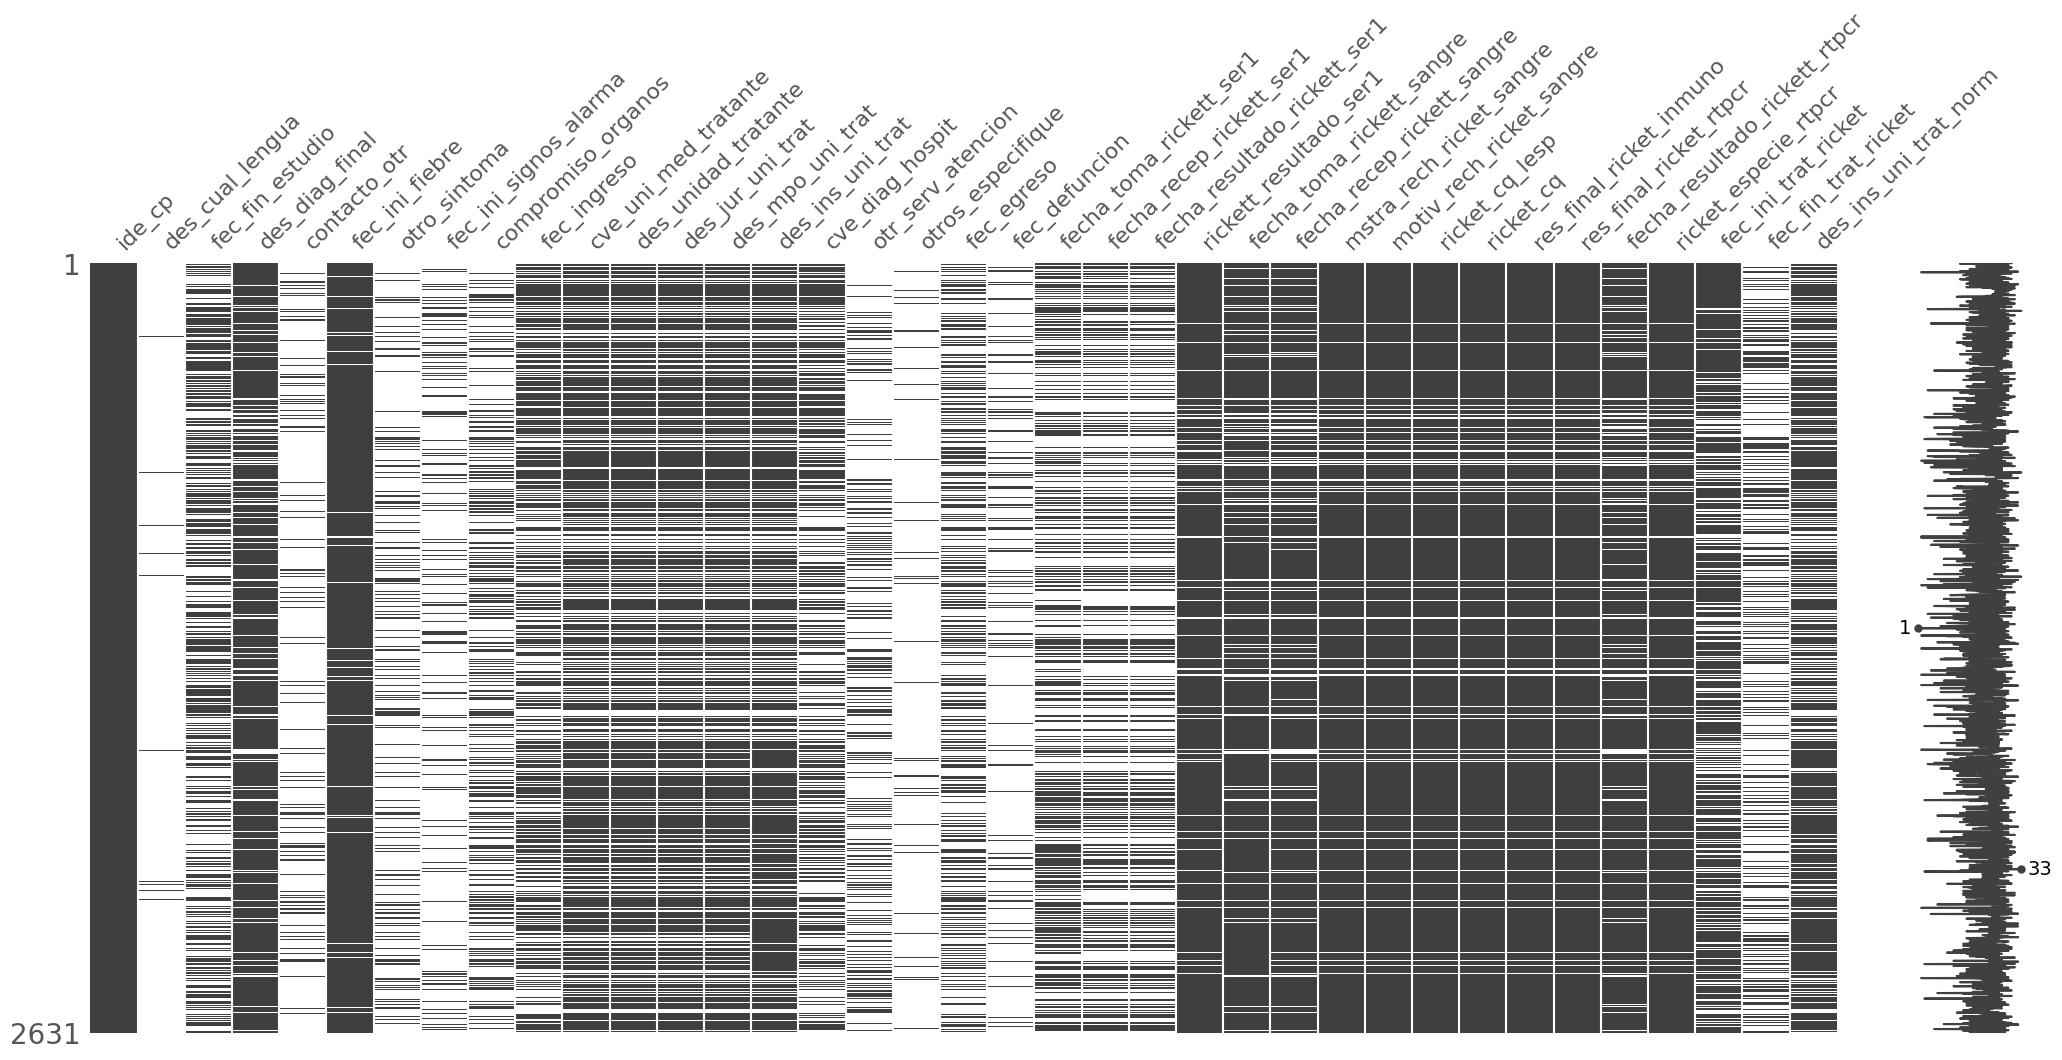

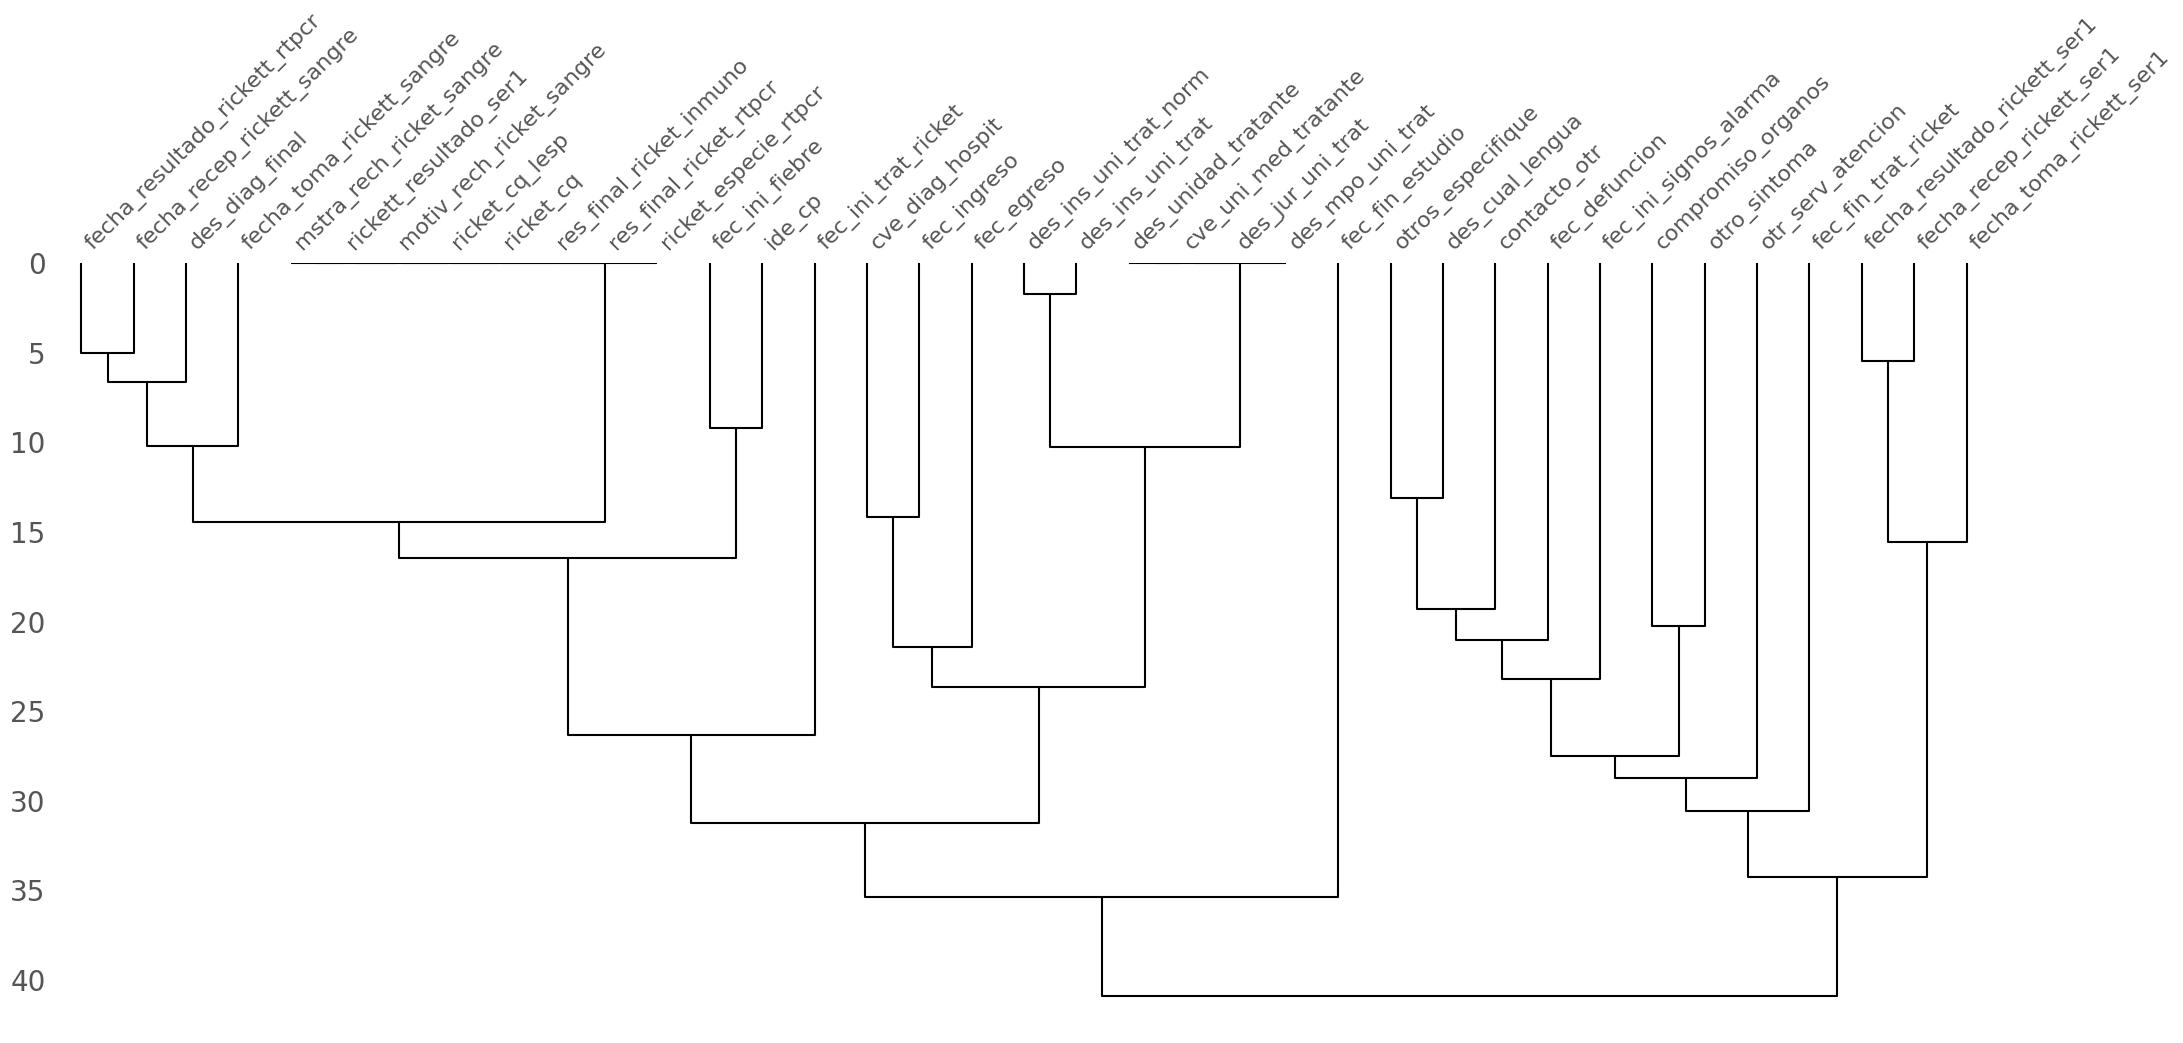

In [513]:
# Identificar columnas que tienen al menos un valor nulo
null_cols = rick.columns[rick.isna().any()].tolist()


# Matriz de completitud
msno.matrix(rick[null_cols])

# Dendrograma: muestra qué variables suelen faltar juntas
msno.dendrogram(rick[null_cols])

<Axes: >

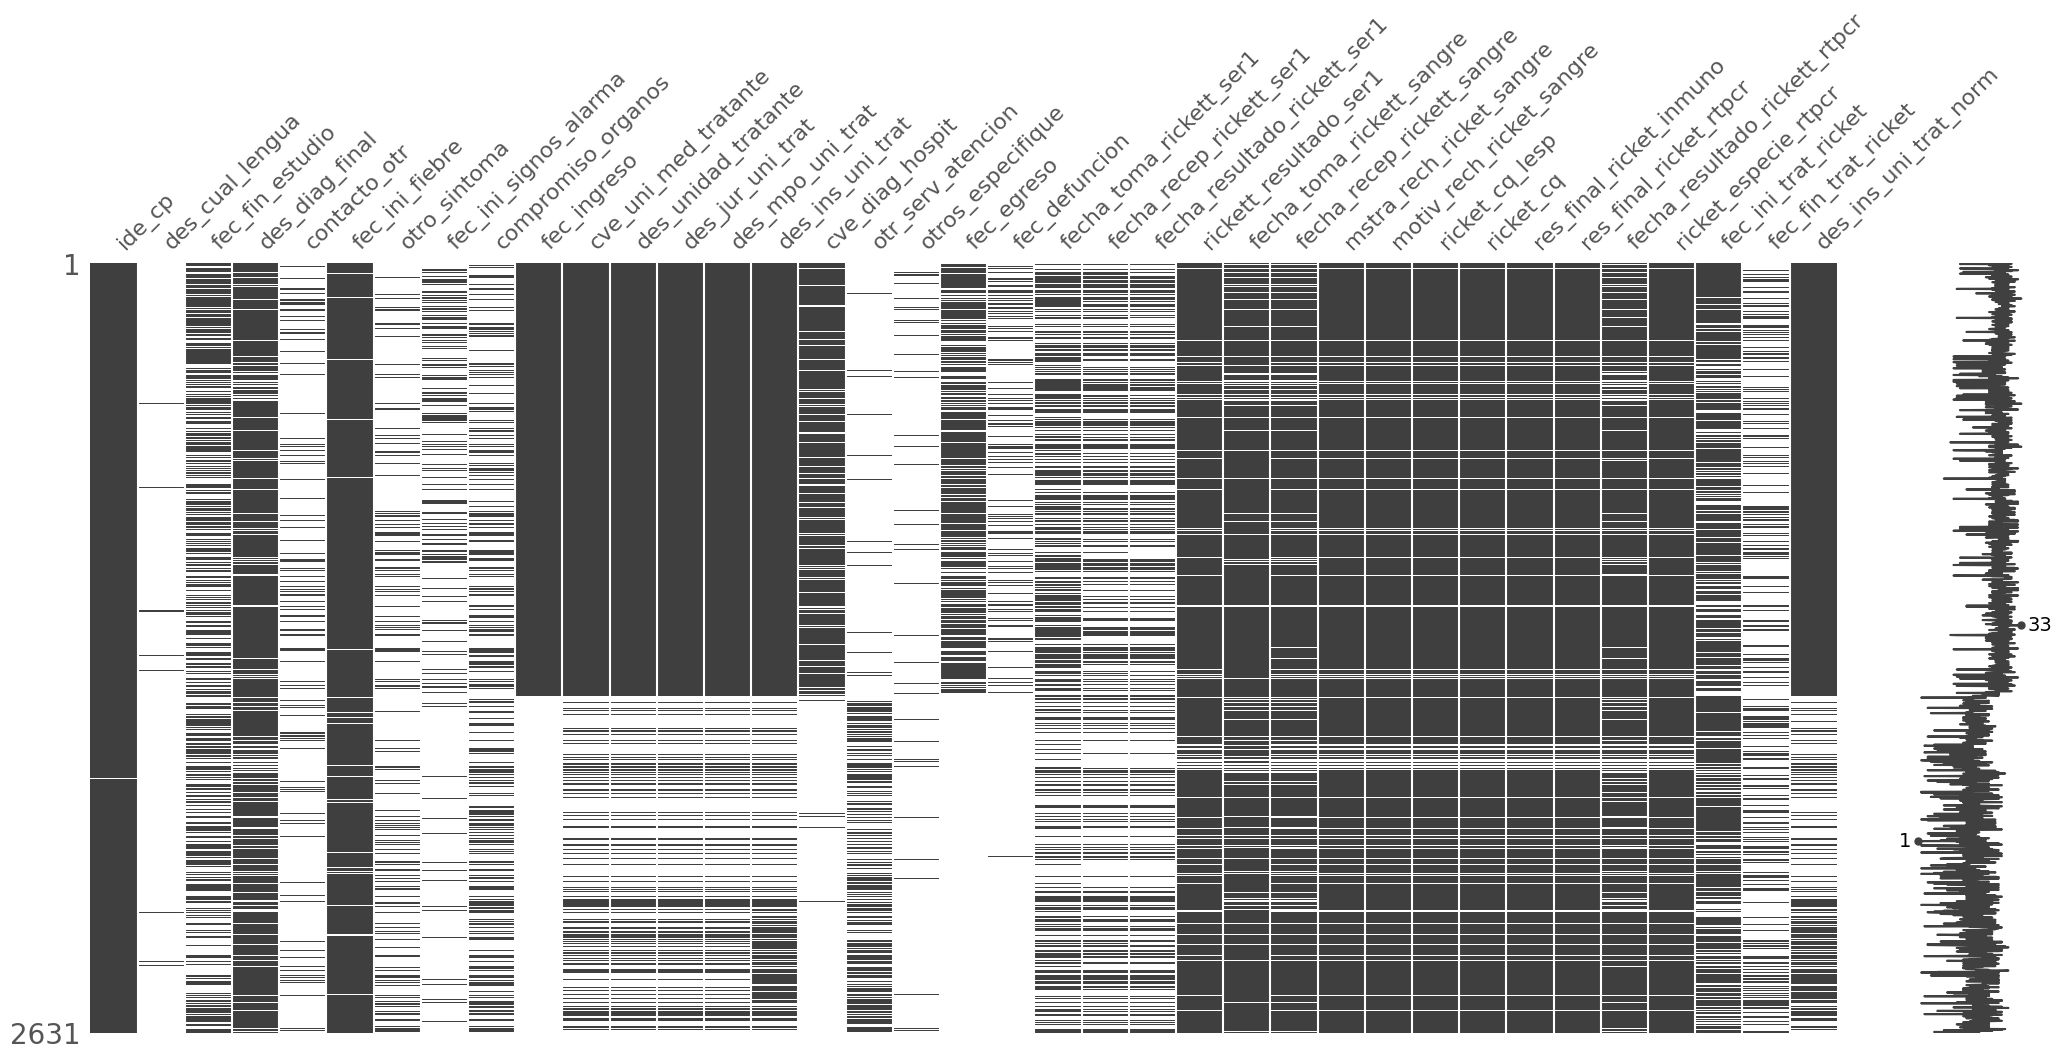

In [514]:
sorted = rick.sort_values('fec_ingreso')
msno.matrix(sorted[null_cols])

### **3.1 Imputación**

In [515]:
# Feature 'des_cual_lengua' - Lengua que habla el paciente

#Indicador de filas imputadas 
rick['des_cual_lengua_imput'] = rick['des_cual_lengua'].isnull().astype('category')

# Imputaremos lo valores nulos con 'Otro' para no perder información
rick['des_cual_lengua'] = rick['des_cual_lengua'].fillna('Otro')
rick['des_cual_lengua'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\2166021503.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['des_cual_lengua_imput'] = rick['des_cual_lengua'].isnull().astype('category')


des_cual_lengua
Otro          2597
Yaqui            9
Guarijío         7
Triqui           5
Mayo             4
Seri             3
Tzeltal          2
Tarahumara       1
Mixteco          1
Náhuatl          1
Totonaca         1
Name: count, dtype: int64

In [516]:
#Corrección de valores nulos
rick.loc[rick['es_indigena'] == 9, 'es_indigena'] = 2

In [517]:
# Feature 'otros_especifique' - El paciente presenta otra comorbilidad
#Indicador de filas imputadas 
rick['otros_especifique_imput'] = rick['otros_especifique'].isnull().astype('category')

# Imputaremos lo valores nulos con 'No' para no perder información
rick['otros_especifique'] = rick['otros_especifique'].fillna('No')
rick['otros_especifique'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\2757969430.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['otros_especifique_imput'] = rick['otros_especifique'].isnull().astype('category')


otros_especifique
No                                    2493
ASMA                                    14
HIPOTIROIDISMO                          11
EPILEPSIA                                7
HIPERPLASIA PROSTATICA BENIGNA           4
                                      ... 
DERMATITIS ATOPICA                       1
DESGARRO HOMBRO / GONARTROSIS            1
LINFOMA DE HODKING                       1
ENFERMEDAD DE LYNE, HIPOTIROIDISMO       1
SINUSITIS CRONICA                        1
Name: count, Length: 99, dtype: int64

In [518]:
rick['contacto_otr'].unique()

<StringArray>
[                   nan,              'RATONES',               'PERROS',
  'CUENTA CON 2 PERROS',               'NEGADO', 'PERROS CON GARRAPATA',
             'ZOONOSIS',                  'CAN',                'PERRO',
             '2 PERROS',     'PERRO PARASITADO',    'PERROS CALLEJEROS',
            '20 PERROS', 'PERRO  ECTOPARASITOS', 'NATURALEZA E INSECTO',
                   'NO', 'PERRO CON GARRAPATAS',             '8 PERROS',
             '6 PERROS',         'PERRO Y GATO',       'PACIENTESEDADO',
  'PERRO CON RICKETSIA', 'PERRO CON ECTOPARASI',       'GATOS Y PERROS',
                'CANES', 'PERRO + ECTOPARASITO',               'PULGAS',
       'PERROS Y GATOS',              'PERRO ,',      'PERROS CABALLOS',
             'NEGATIVO',             '3 PERROS', '3 PERROS ECTOPARASIT',
 'PERROS + ECTOPARASIT', 'PERROS ECTOPARASITOS',              'CONEJOS',
                'GATOS',      'NIEGA PRESENCIA',       'TIENE MASCOTAS',
  'PLAGA DE GARRAPATAS',             

In [519]:
mapa_contacto_otr = {
    # ── SIN CONTACTO / NEGADO ────────────────────────────────────────────────
    'NEGADO':               'Sin contacto',
    'NEGATIVO':             'Sin contacto',
    'NO':                   'Sin contacto',
    'NIEGA PRESENCIA':      'Sin contacto',
    'NO HA VISTO':          'Sin contacto',
    'SE IGNORA':            'Sin contacto',
    'PACIENTESEDADO':       'Sin contacto',

    # ── SOLO PERROS (sin mención de ectoparásitos) ───────────────────────────
    'PERRO':                'Perros',
    'PERRO ,':              'Perros',
    'CAN':                  'Perros',
    'CANES':                'Perros',
    'PERROS':               'Perros',
    '2 PERROS':             'Perros',
    '3 PERROS':             'Perros',
    '6 PERROS':             'Perros',
    '8 PERROS':             'Perros',
    '20 PERROS':            'Perros',
    'PERROS 9':             'Perros',
    'CUENTA CON 2 PERROS':  'Perros',
    'TIENE PERROS SU CASO': 'Perros',
    'PERROS EN SU CASA':    'Perros',
    'PERROS CALLEJEROS':    'Perros',

    # ── PERRO CON ECTOPARÁSITOS ──────────────────────────────────────────────
    'PERRO PARASITADO':     'Perros con ectoparásitos',
    'PERRO  ECTOPARASITOS': 'Perros con ectoparásitos',
    'PERRO ECTOPARASITOS':  'Perros con ectoparásitos',
    'PERRO CON ECTOPARASI': 'Perros con ectoparásitos',
    'PERRO CON EXTOPARASI': 'Perros con ectoparásitos',
    'PERRO + ECTOPARASITO': 'Perros con ectoparásitos',
    'PERROS + ECTOPARASIT': 'Perros con ectoparásitos',
    'PERROS CON ECTOPARAS': 'Perros con ectoparásitos',
    'PERROS ECTOPARASITOS': 'Perros con ectoparásitos',
    '3 PERROS ECTOPARASIT': 'Perros con ectoparásitos',
    'PERRO C/ ECTOPARASIT': 'Perros con ectoparásitos',

    # ── PERRO CON GARRAPATAS ─────────────────────────────────────────────────
    'PERROS CON GARRAPATA': 'Perros con garrapatas',
    'PERRO CON GARRAPATAS': 'Perros con garrapatas',
    'PERRO CON RICKETSIA':  'Perros con garrapatas',
    'PERROCON GARRAPATAS':  'Perros con garrapatas',
    'PERROS + GARRAPATAS':  'Perros con garrapatas',
    'PERROVECINOGARRAPATA': 'Perros con garrapatas',
    'CASA/PERRO GARRAPATA': 'Perros con garrapatas',

    # ── PERRO Y GATO ─────────────────────────────────────────────────────────
    'PERRO Y GATO':         'Perros y gatos',
    'PERRO , GATO':         'Perros y gatos',
    'PERRO/GATOS':          'Perros y gatos',
    'PERRO Y GATOS':        'Perros y gatos',
    'GATOS Y PERROS':       'Perros y gatos',
    'PERROS Y GATOS':       'Perros y gatos',
    '5 PERROS Y 13 GATOS':  'Perros y gatos',
    'COCHIS,PERROS Y GATO': 'Perros y gatos',

    # ── SOLO GATOS ───────────────────────────────────────────────────────────
    'GATO':                 'Gatos',
    'GATOS':                'Gatos',

    # ── ROEDORES ─────────────────────────────────────────────────────────────
    'RATONES':              'Roedores',
    'RATAS':                'Roedores',
    'ROEDORES':             'Roedores',

    # ── OTROS ANIMALES ───────────────────────────────────────────────────────
    'CONEJOS':              'Conejos',
    'PERROS CABALLOS':      'Perros y caballos',
    'TIENE MASCOTAS':       'Otros animales',

    # ── GARRAPATAS / INSECTOS (sin animal específico) ────────────────────────
    'PLAGA DE GARRAPATAS':  'Garrapatas',
    'GARRAPATA EN CASA':    'Garrapatas',
    'SE RETIRO GARRAPATA':  'Garrapatas',
    'PULGAS':               'Pulgas',
    'ARAÑAS':               'Arañas',
    'PICADURA DE INSECTO':  'Insectos no especificados',
    'NATURALEZA E INSECTO': 'Insectos no especificados',
    
    # ZOONOSIS (sin animal específico) ─────────────────────────────────────────
    'ZOONOSIS':             'Zoonosis',
    'ZOONOSIS POSITIVA':    'Zoonosis',

    # ── EXPOSICIÓN AMBIENTAL ─────────────────────────────────────────────────
    'INTRADOMICILIARIO':    'Exposición ambiental',
    'DUERME EN EL PISO':    'Exposición ambiental',
}

rick['contacto_otr'] = rick['contacto_otr'].map(mapa_contacto_otr)

# Verificar resultado
print(rick['contacto_otr'].value_counts(dropna=False))

contacto_otr
NaN                          2315
Perros                        229
Perros con ectoparásitos       20
Perros y gatos                 19
Sin contacto                   16
Perros con garrapatas           9
Roedores                        4
Pulgas                          3
Gatos                           3
Garrapatas                      3
Zoonosis                        2
Insectos no especificados       2
Exposición ambiental            2
Perros y caballos               1
Conejos                         1
Otros animales                  1
Arañas                          1
Name: count, dtype: int64


In [520]:
# Feature 'contacto_otr' - El paciente tuvo contacto con otro animal

#Indicador de filas imputadas 
rick['contacto_otr_imput'] = rick['contacto_otr'].isnull().astype('category')

# Imputaremos lo valores nulos con 'Se ignora' para no perder información
rick['contacto_otr'] = rick['contacto_otr'].fillna('Sin contacto')
rick['contacto_otr'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\1193158268.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['contacto_otr_imput'] = rick['contacto_otr'].isnull().astype('category')


contacto_otr
Sin contacto                 2331
Perros                        229
Perros con ectoparásitos       20
Perros y gatos                 19
Perros con garrapatas           9
Roedores                        4
Pulgas                          3
Gatos                           3
Garrapatas                      3
Zoonosis                        2
Insectos no especificados       2
Exposición ambiental            2
Perros y caballos               1
Conejos                         1
Otros animales                  1
Arañas                          1
Name: count, dtype: int64

In [521]:
# Feature 'otro_sintoma' - El paciente presenta otro síntoma

#Indicador de filas imputadas 
rick['otro_sintoma_imput'] = rick['otro_sintoma'].isnull().astype('category')

# Imputaremos lo valores nulos con 'No' para no perder información
rick['otro_sintoma'] = rick['otro_sintoma'].fillna('NO')
rick['otro_sintoma'] = rick['otro_sintoma'].str.replace('NINGUNO', 'NO', regex=False)
rick['otro_sintoma'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\2651080628.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['otro_sintoma_imput'] = rick['otro_sintoma'].isnull().astype('category')


otro_sintoma
NO                                                                                      2220
2                                                                                        381
IRRITABILIDAD                                                                              1
LESION TIPO PAPULA DE 0.5 CM DIAM                                                          1
TAQUIPNEA                                                                                  1
EVACUACIONES DIARREICAS                                                                    1
TROMBOCITOPENIA                                                                            1
HIPEREMIA CONJUNTIVAL                                                                      1
HIGADO                                                                                     1
HIPOTIROIDISMO                                                                             1
LESION RENAL AGUDA                                       

In [522]:
# Feature 'otr_serv_atencion' - El paciente recibió otro tipo de servicio
rick['otr_serv_atencion'].value_counts(dropna=False)

otr_serv_atencion
NaN                                      2006
EPIDEMIOLOGIA                             251
CONSULTA EXTERNA                          162
MEDICINA FAMILIAR                          66
URGENCIAS PEDIATRICAS                      44
                                         ... 
CONSULTA EXTERNA DE MEDICINA FAMILIAR       1
EPIDEMIOLOGICO                              1
CONUSLTA EPIDEMIOLOGIA                      1
MEDCINA PREVENTIVA                          1
SIN ATENCION MEDICA                         1
Name: count, Length: 74, dtype: int64

In [523]:
mapa_otr_serv_atencion = {
    # ── EPIDEMIOLOGÍA ────────────────────────────────────────────────────────
    'EPIDEMIOLOGIA':                          'Epidemiologia',
    'EPIDEMIOLOGÍA':                          'Epidemiologia',
    'EPIDEMILOGIA':                           'Epidemiologia',
    'EPIDEMIOLGIA':                           'Epidemiologia',
    'EPIEDEMIOLOGIA':                         'Epidemiologia',
    'EPIDEMIPOLOGIA':                         'Epidemiologia',
    'PIDEMIOLOGIA':                           'Epidemiologia',
    'EPIDEMILOGIA':                           'Epidemiologia',
    'EPIDEMIOLOGICA':                         'Epidemiologia',
    'EPIDEMIOLOGICO':                         'Epidemiologia',
    'EPIDEMIOLOGO':                           'Epidemiologia',
    'DEPTO. EPIDEMIOLOGIA':                   'Epidemiologia',
    'SERVICIO EPIDEMIOLOGIA':                 'Epidemiologia',
    'CONSULTA EPIDEMIOLOGIA':                 'Epidemiologia',
    'CONSULTA EPIDEMIOLOGÍA':                 'Epidemiologia',
    'CONUSLTA EPIDEMIOLOGIA':                 'Epidemiologia',
    'EPIDEMIOLOGIA CLINICA':                  'Epidemiologia',
    'EPIDEMIOLOGIA UMF NO.1':                 'Epidemiologia',
    'EPIDEMIOLOGIA COORDINACION HUATABAMPO':  'Epidemiologia',
    'EPI':                                    'Epidemiologia',

    # ── EPIDEMIOLOGÍA + CONSULTA EXTERNA ─────────────────────────────────────
    'EPIDEMIOLOGIA/MEDICINA FAMILIAR':        'Epidemiologia y consulta externa',
    'EPIDEMIOLOGIA CONSULTA EXTERNA':         'Epidemiologia y consulta externa',
    'CONSULTA EXTERNA EPIDEMIOLOGIA':         'Epidemiologia y consulta externa',
    'CONSULTA EXTERNA EPIDEMIOLOGÍA':         'Epidemiologia y consulta externa',

    # ── CONSULTA EXTERNA ─────────────────────────────────────────────────────
    'CONSULTA EXTERNA':                       'Consulta externa',
    'CONSULTA  EXTERNA':                      'Consulta externa',
    'CONSULTA EXTERA':                        'Consulta externa',
    'CONSULTA EXTERNA GENERAL':               'Consulta externa',
    'CONSULTA EXTERNA MG':                    'Consulta externa',
    'CONSULTA':                               'Consulta externa',

    # ── MEDICINA FAMILIAR ────────────────────────────────────────────────────
    'MEDICINA FAMILIAR':                      'Medicina familiar',
    'MEDICINA FAMILAIR':                      'Medicina familiar',
    'MEDICO FAMILIAR':                        'Medicina familiar',
    'MEDIFICNA FAMILIAR':                     'Medicina familiar',
    'MF':                                     'Medicina familiar',
    'UMF 68':                                 'Medicina familiar',
    'CONSULTA EXTERNA FAMILIAR':              'Medicina familiar',
    'CONSULTA EXTERNA MEDICO FAMILIAR':       'Medicina familiar',
    'CONSULTA EXTERNA DE MEDICINA FAMILIAR':  'Medicina familiar',
    'CONSULTA MEDICINA FAMILIAR':             'Medicina familiar',

    # ── MEDICINA GENERAL ─────────────────────────────────────────────────────
    'MEDICINA GENERAL':                       'Medicina general',
    'MEDICO GENERAL':                         'Medicina general',
    'MEH':                                    'Medicina general',

    # ── MEDICINA PREVENTIVA ──────────────────────────────────────────────────
    'MEDICINA PREVENTIVA':                    'Medicina preventiva',
    'MEDCINA PREVENTIVA':                     'Medicina preventiva',

    # ── INFECTOLOGÍA ─────────────────────────────────────────────────────────
    'INFECTOLOGIA':                           'Infectologia',
    'INFECTOLOGIA CAMA 209':                  'Infectologia',

    # ── URGENCIAS PEDIÁTRICAS ────────────────────────────────────────────────
    'URGENCIAS PEDIATRICAS':                  'Urgencias pediatricas',
    'URGENCIAS PEDIÁTRICAS':                  'Urgencias pediatricas',
    'URG PEDIATRICAS':                        'Urgencias pediatricas',

    # ── CUIDADOS INTENSIVOS ──────────────────────────────────────────────────
    'UNIDAD DE CUIDADOS INTENSIVOS PEDIATRICOS': 'UCI pediatrica',

    # ── BRIGADA EPIDEMIOLÓGICA ───────────────────────────────────────────────
    'BRIGADA EPIDEMIOLOGICA':                 'Brigada epidemiologica',
    'BRIGADA EPIDEMIOLÓGICA DS5':             'Brigada epidemiologica',
    'BRIGADIA EPIDEMIOLOGIA':                 'Brigada epidemiologica',
    'BRIGADA DE SALUD EPIDEMIOLOGIA':         'Brigada epidemiologica',
    'BRIGADA DE SALUD EPIDEMIOLOGICA':        'Brigada epidemiologica',
    'BRIGADA DE SALUD':                       'Brigada epidemiologica',
    'BRIGADISTA DE SALUD':                    'Brigada epidemiologica',
    'BRIGADA':                                'Brigada epidemiologica',

    # ── CONSULTA PRIVADA / FARMACIA ──────────────────────────────────────────
    'MEDICO PARTICULAR':                      'Consulta privada',
    'CONSULTORIO PRIVADO':                    'Consulta privada',
    'FARMACIA':                               'Consulta en farmacia',
    'CONSULTORIO FARMACIA DEL AHORRO':        'Consulta en farmacia',
    'CONSULTA EN FARMACIA PARTICULAR':        'Consulta en farmacia',
    'ATENCION MEDICA EN FARMACIA BENAVIDES':  'Consulta en farmacia',
    'CONSULTORIO DE FARMACIA SIMILAR SANTA CLARA 1 COL VILLAS DEL SUR': 'Consulta en farmacia',

    # ── HOSPITAL PRIVADO ─────────────────────────────────────────────────────
    'HOSPITAL SAN JOSÉ GUAYMAS':              'Hospital privado',
    'HOSPITAL SAN JOSE GUAYMAS':              'Hospital privado',

    # ── ATENCIÓN CONTINUA ────────────────────────────────────────────────────
    'ATENCION MEDICA CONTINUA':               'Atencion continua',
    'ATENCION CONTINUA':                      'Atencion continua',

    # ── SEMEFO ───────────────────────────────────────────────────────────────
    'SEMEFO':                                 'SEMEFO',

    # ── SIN ATENCIÓN MÉDICA ──────────────────────────────────────────────────
    'SIN ATENCION MEDICA':                    'Sin atencion medica',
}

rick['otr_serv_atencion'] = rick['otr_serv_atencion'].map(mapa_otr_serv_atencion)

In [524]:
# Feature 'otr_serv_atencion' - El paciente recibió otro tipo de servicio
rick['otr_serv_atencion'].value_counts(dropna=False)

otr_serv_atencion
NaN                                 2010
Epidemiologia                        273
Consulta externa                     169
Medicina familiar                     79
Urgencias pediatricas                 49
Epidemiologia y consulta externa      17
Brigada epidemiologica                 9
Consulta en farmacia                   5
Medicina preventiva                    4
Infectologia                           3
Medicina general                       3
Atencion continua                      3
Hospital privado                       2
Consulta privada                       2
SEMEFO                                 1
UCI pediatrica                         1
Sin atencion medica                    1
Name: count, dtype: int64

In [525]:
#Indicador de filas imputadas 
rick['otr_serv_atencion_imput'] = rick['otr_serv_atencion'].isna().astype('category')

# Imputaremos lo valores nulos con 'Se ignora' para no perder información
rick['otr_serv_atencion'] = rick['otr_serv_atencion'].fillna('Se ignora')
rick['otr_serv_atencion'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\763547958.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['otr_serv_atencion_imput'] = rick['otr_serv_atencion'].isna().astype('category')


otr_serv_atencion
Se ignora                           2010
Epidemiologia                        273
Consulta externa                     169
Medicina familiar                     79
Urgencias pediatricas                 49
Epidemiologia y consulta externa      17
Brigada epidemiologica                 9
Consulta en farmacia                   5
Medicina preventiva                    4
Infectologia                           3
Medicina general                       3
Atencion continua                      3
Hospital privado                       2
Consulta privada                       2
SEMEFO                                 1
UCI pediatrica                         1
Sin atencion medica                    1
Name: count, dtype: int64

In [526]:
# Feature 'compromiso_organos' - El paciente presenta compromiso de órganos
rick['compromiso_organos'].unique()

<StringArray>
[                                   nan,
                                   'NO',
                                    '2',
                             'PULMONAR',
                    'NO POR EL MOMENTO',
                  'FALLA MULTIORGANICA',
                     'NINGUNO APARENTE',
                              'NINGUNO',
                                'RIÑON',
                                    '1',
            'INSUFICIENCIA RENAL AGUDA',
                             'NEGATIVO',
                          'FALLA RENAL',
                    'HEMATOMA EPIDURAL',
                       'PACIENTE GRAVE',
                     'HEPATICA Y RENAL',
                                'RENAL',
              'FALLA ORGANICA MULTIPLE',
                     'ESTADO DE CHOQUE',
                                   'SI',
         'ESTETATOSIS HEPATICA GRADO 1',
                              'NEGADOS',
                  'INSUFICIENCIA RENAL',
                           'EL CEREBRO',
  

### 3.2 **Outliers**

count   2631.00
mean      37.64
std        6.07
min        0.00
25%       38.00
50%       39.00
75%       39.00
max       43.00
Name: temperatura, dtype: float64

Nulos: 0


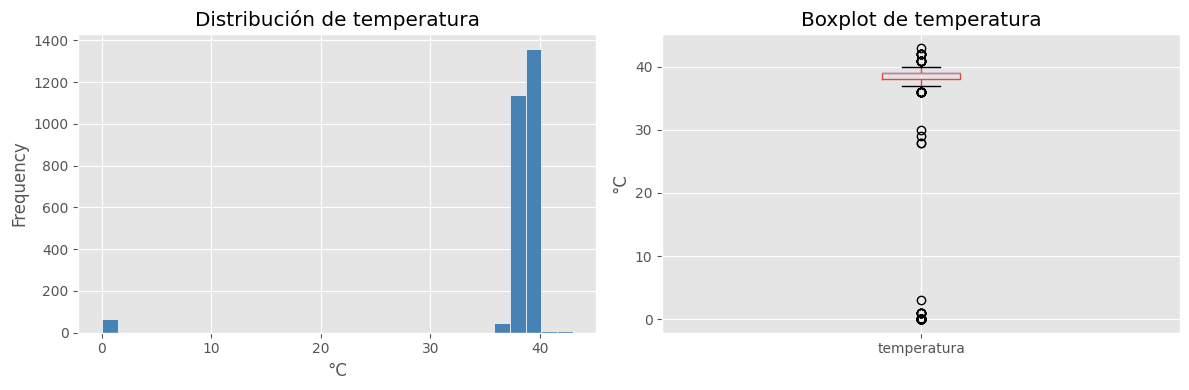

In [527]:
print(rick['temperatura'].describe().round(2))
print(f"\nNulos: {rick['temperatura'].isna().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rick['temperatura'].plot(kind='hist', bins=30, ax=axes[0],
                         color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de temperatura')
axes[0].set_xlabel('°C')

rick.boxplot(column='temperatura', ax=axes[1])
axes[1].set_title('Boxplot de temperatura')
axes[1].set_ylabel('°C')

plt.tight_layout()
plt.show()

In [528]:
# IQR
Q1 = rick['temperatura'].quantile(0.25)
Q3 = rick['temperatura'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers_iqr = rick[(rick['temperatura'] < limite_inf) |
                    (rick['temperatura'] > limite_sup)]
print(f"\nOutliers por IQR: {len(outliers_iqr)} casos")
print(f"Límites IQR: [{limite_inf:.1f}, {limite_sup:.1f}] °C")
print(outliers_iqr['temperatura'].value_counts().sort_index())


Outliers por IQR: 102 casos
Límites IQR: [36.5, 40.5] °C
temperatura
0     59
1      6
3      1
28     2
29     1
30     1
36    17
41     8
42     6
43     1
Name: count, dtype: int64


Se procederá con otro método de detección de outliers, ya que utilizando el IQR, podriamos estar eliminando valores válidos (ej. temperaturas de 32-42°). 
Acorde al NIH (National Instutes of Health):

"Los límites clínicos de temperatura corporal humana oscilan entre los **24°C** o 75.2°F en el extremo inferior y los **43°C** o 109.4°F en el extremo superior. Un registro en el límite inferior indica una hipotermia profunda, un estado crítico donde el metabolismo celular se ralentiza drásticamente, los reflejos desaparecen y el cuerpo entra en un coma que precede al paro cardiorrespiratorio inminente. Por el contrario, alcanzar el límite superior indica una hipertermia extrema o golpe de calor severo, una emergencia médica donde los mecanismos de termorregulación fallan por completo, provocando la desnaturalización de las proteínas celulares, daño cerebral irreversible y una falla multiorgánica rápida."

In [529]:
#Z-score (para detectar valores extremos muy alejados)

z_scores = stats.zscore(rick['temperatura'].dropna())
outliers_z = rick.loc[rick['temperatura'].dropna().index][abs(z_scores) > 3]
print(f"\nOutliers por Z-score (|z| > 3): {len(outliers_z)} casos")
print(outliers_z['temperatura'].value_counts().sort_index())


Outliers por Z-score (|z| > 3): 66 casos
temperatura
0    59
1     6
3     1
Name: count, dtype: int64


In [530]:
temp_valida = rick['temperatura'].dropna()
z_scores_s = pd.Series(stats.zscore(temp_valida), index=temp_valida.index)
rick.loc[abs(z_scores_s) > 3, 'temperatura'] = np.nan
print(f"\nOutliers convertidos a NaN. Nulos ahora: {rick['temperatura'].isna().sum()}")
print(f'Porcentaje de nulos en "temperatura": {((rick['temperatura'].isna().sum() / len(rick))*100).round(2)}%')


Outliers convertidos a NaN. Nulos ahora: 66
Porcentaje de nulos en "temperatura": 2.51%


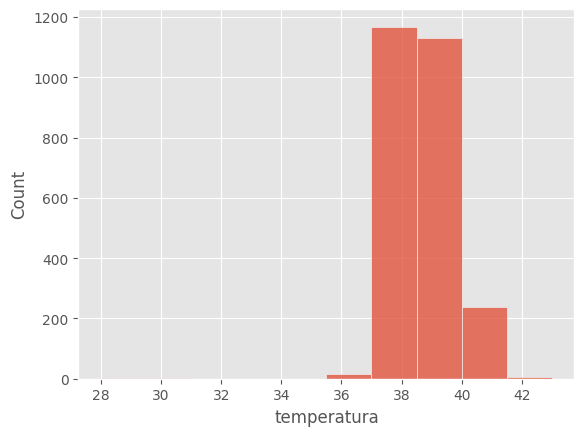

In [531]:
sns.histplot(rick['temperatura'], bins = 10)
plt.show()

In [532]:
#Indicador de imputación
rick['temperatura_imput'] = rick['temperatura'].isnull().astype('category')

#Imputacion con mediana
mediana_temp = rick['temperatura'].median()
rick['temperatura'] = rick['temperatura'].fillna(mediana_temp)
print(f"Nulos restantes en temperatura: {rick['temperatura'].isnull().sum()}")
print(f"Valor de la mediana utilizada: {mediana_temp:.2f}°C")

Nulos restantes en temperatura: 0
Valor de la mediana utilizada: 39.00°C


C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\3134809887.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['temperatura_imput'] = rick['temperatura'].isnull().astype('category')


## **4. Feature Engineering**

### 4.1 Definir tipo de features

4.1.1 **Features de tipo datetime**

In [533]:
# Columnas datetime

#Extracción de fecha unicamente (sin hora)

# Identificar las columnas que empiezan con 'fec_'
cols_fecha = [col for col in rick.columns if col.startswith(('fec_', 'fecha'))]


for col in cols_fecha:    
    rick[col] = pd.to_datetime(rick[col], errors='coerce')

print(f"Se convirtieron {len(cols_fecha)} columnas.")
print(rick[cols_fecha].dtypes.head(20))

print("Ejemplo de conversión de fecha:")
rick[cols_fecha].head()

Se convirtieron 17 columnas.
fec_sol_aten                     datetime64[us]
fec_ini_estudio                  datetime64[us]
fec_fin_estudio                  datetime64[us]
fec_ini_signos_sint              datetime64[us]
fec_ini_fiebre                   datetime64[us]
fec_ini_signos_alarma            datetime64[us]
fec_ingreso                      datetime64[us]
fec_egreso                       datetime64[us]
fec_defuncion                    datetime64[us]
fecha_toma_rickett_ser1          datetime64[us]
fecha_recep_rickett_ser1         datetime64[us]
fecha_resultado_rickett_ser1     datetime64[us]
fecha_toma_rickett_sangre        datetime64[us]
fecha_recep_rickett_sangre       datetime64[us]
fecha_resultado_rickett_rtpcr    datetime64[us]
fec_ini_trat_ricket              datetime64[us]
fec_fin_trat_ricket              datetime64[us]
dtype: object
Ejemplo de conversión de fecha:


,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,fec_ingreso,fec_egreso,fec_defuncion,fecha_toma_rickett_ser1,fecha_recep_rickett_ser1,fecha_resultado_rickett_ser1,fecha_toma_rickett_sangre,fecha_recep_rickett_sangre,fecha_resultado_rickett_rtpcr,fec_ini_trat_ricket,fec_fin_trat_ricket
0,2022-01-02,2022-01-02,2022-01-09,2021-12-31,2021-12-31,2022-01-01,2022-01-01,2022-02-14,NaT,2022-01-01,2022-01-02,2022-01-09,2022-01-01,2022-01-02,2022-01-05,2022-01-01,2022-01-04
1,2022-01-05,2022-01-05,NaT,2022-01-04,2022-01-04,NaT,NaT,NaT,NaT,2022-01-05,2022-01-12,2022-01-17,2022-01-05,2022-01-12,2022-01-13,2022-01-05,NaT
2,2022-01-05,2022-01-06,2022-01-06,2022-01-02,2022-01-02,NaT,2022-01-05,2022-01-07,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2022-01-06,NaT
3,2022-01-10,2022-01-10,NaT,2022-01-07,2022-01-08,NaT,NaT,NaT,NaT,2022-01-10,2022-01-12,2022-01-17,2022-01-10,2022-01-12,2022-01-13,2022-01-10,NaT
4,2022-01-13,2022-01-14,2022-02-07,2022-01-05,2022-01-05,NaT,2022-01-13,2022-02-01,NaT,2022-01-14,2022-01-17,2022-01-19,NaT,NaT,NaT,2022-01-14,NaT


4.1.2 **Features de tipo categórico**

In [534]:
for i, v in enumerate(rick.columns):
    print(f"Índice: {i}  |  Columna: {v}")

Índice: 0  |  Columna: ide_id
Índice: 1  |  Columna: ide_sex
Índice: 2  |  Columna: ide_eda_ano
Índice: 3  |  Columna: des_cal
Índice: 4  |  Columna: ide_col
Índice: 5  |  Columna: des_jur_res
Índice: 6  |  Columna: des_mpo_res
Índice: 7  |  Columna: cve_loc_res
Índice: 8  |  Columna: des_loc_res
Índice: 9  |  Columna: ide_cp
Índice: 10  |  Columna: es_indigena
Índice: 11  |  Columna: lengua_indigena
Índice: 12  |  Columna: des_cual_lengua
Índice: 13  |  Columna: des_ocupacion
Índice: 14  |  Columna: estatus_caso
Índice: 15  |  Columna: fec_sol_aten
Índice: 16  |  Columna: fec_ini_estudio
Índice: 17  |  Columna: fec_fin_estudio
Índice: 18  |  Columna: des_diag_probable
Índice: 19  |  Columna: des_diag_final
Índice: 20  |  Columna: contacto_garrapata
Índice: 21  |  Columna: contacto_otr
Índice: 22  |  Columna: agua_potable
Índice: 23  |  Columna: eliminacion_basura
Índice: 24  |  Columna: fec_ini_signos_sint
Índice: 25  |  Columna: fec_ini_fiebre
Índice: 26  |  Columna: temperatura
Índi

In [535]:
#Columnas categóricas
cat_cols = list(rick.columns[0:2]) + \
           list(rick.columns[3:15]) + \
           list(rick.columns[18:24]) + \
           list(rick.columns[27:39]) + \
           list(rick.columns[40:121]) + \
           list(rick.columns[122:138]) + \
           list(rick.columns[139:142]) + \
           list(rick.columns[147:149]) + \
           list(rick.columns[150:151]) + \
           list(rick.columns[152:154]) + \
           list(rick.columns[157:158]) + \
           list(rick.columns[160:162]) + \
           list(rick.columns[164:166]) + \
           list(rick.columns[167:169]) + \
           list(rick.columns[171:173])
           
print(cat_cols)

['ide_id', 'ide_sex', 'des_cal', 'ide_col', 'des_jur_res', 'des_mpo_res', 'cve_loc_res', 'des_loc_res', 'ide_cp', 'es_indigena', 'lengua_indigena', 'des_cual_lengua', 'des_ocupacion', 'estatus_caso', 'des_diag_probable', 'des_diag_final', 'contacto_garrapata', 'contacto_otr', 'agua_potable', 'eliminacion_basura', 'cefalea', 'mialgias', 'artralgias', 'poliartralgias', 'artritis', 'dolor_retroocular', 'exantema', 'nauseas', 'vomito', 'petequias', 'torniquete_positivo', 'otro_sintoma', 'vomito_persistentes', 'dolor_abdominal_intenso', 'acumulacion_liquidos', 'sangrado_mucosas', 'letargo', 'irritabilidad', 'hipotension_postural', 'hepatomegalia', 'aumento_hematocrito', 'escape_plasma', 'taquicardia', 'extremidades_frias', 'llenado_capilar', 'presion_convergente', 'hipotension_arterial', 'insuficiencia_respiratoria', 'hematemesis', 'melena', 'metrorragia_voluminosa', 'sangrado_snc', 'ast_alt', 'alteraciones_conciencias', 'miocarditis', 'compromiso_organos', 'dolor_espalda', 'prurito', 'diaf

In [536]:
rick[cat_cols] = rick[cat_cols].astype('category')

In [537]:
rick.dtypes.head(25)

ide_id                       category
ide_sex                      category
ide_eda_ano                     int64
des_cal                      category
ide_col                      category
des_jur_res                  category
des_mpo_res                  category
cve_loc_res                  category
des_loc_res                  category
ide_cp                       category
es_indigena                  category
lengua_indigena              category
des_cual_lengua              category
des_ocupacion                category
estatus_caso                 category
fec_sol_aten           datetime64[us]
fec_ini_estudio        datetime64[us]
fec_fin_estudio        datetime64[us]
des_diag_probable            category
des_diag_final               category
contacto_garrapata           category
contacto_otr                 category
agua_potable                 category
eliminacion_basura           category
fec_ini_signos_sint    datetime64[us]
dtype: object

### 4.2 **Eliminación de features redundantes**

In [538]:
rick = rick.drop('des_diag_probable', axis=1)

### 4.3 **Creación de features**

In [539]:
# Feature 'compromiso_organos' - El paciente presenta compromiso de órganos
# La variable original especifica el tipo de compromiso de órganos, 
# La convertiremos a una variable binaria que indique si el paciente tiene o no compromiso de órganos

rick['compromiso_organos'].unique()

# Valores que indican AUSENCIA de compromiso de órganos
sin_compromiso = {
    'NO', 'NO POR EL MOMENTO', 'NINGUNO APARENTE', 'NINGUNO',
    'NEGATIVO', 'NEGADOS', 'NEGAGO', '2'
}

# Valores que indican PRESENCIA de compromiso de órganos
con_compromiso = {
    'PULMONAR', 'FALLA MULTIORGANICA', 'RIÑON', 'INSUFICIENCIA RENAL AGUDA',
    'FALLA RENAL', 'HEMATOMA EPIDURAL', 'PACIENTE GRAVE', 'HEPATICA Y RENAL',
    'RENAL', 'FALLA ORGANICA MULTIPLE', 'ESTADO DE CHOQUE',
    'ESTETATOSIS HEPATICA GRADO 1', 'INSUFICIENCIA RENAL', 'EL CEREBRO',
    'RENAL, HEPATICO', 'LRA', 'DEL SISTEMA NERVIOSO',
    'HECES FECALES CON SANGRE', 'MO', 'LESION RENAL AGUDA',
    'RENAL Y RESPIRATORIO', '1 FALLA RENAL', 'INSUFICIENCIA HEPATICA',
    'ETV', 'FALLA HEMATOLOGICA, RENAL Y HEPATICA', 'ERITEMA',
    'SI', '1', 'HEPATICA Y RENAL',
}

# Valores ambiguos que no se pueden clasificar con certeza
ambiguos = {'PACIENTE GRAVE', '22'}

def clasificar_compromiso(valor):
    if pd.isna(valor):
        return 0  # Consideramos nulos como ambiguos
    valor = str(valor).strip().upper()
    if valor in sin_compromiso:
        return 2   # No
    elif valor in con_compromiso:
        return 1   # Sí
    else:
        return 0  # ambiguo o no reconocido

rick['compromiso_organos_binario'] = rick['compromiso_organos'].apply(clasificar_compromiso)
rick['compromiso_organos_binario'] = rick['compromiso_organos_binario'].astype('category')

# Verificar
print(rick['compromiso_organos_binario'].value_counts(dropna=False))

compromiso_organos_binario
0    1763
2     792
1      76
Name: count, dtype: int64


In [540]:
# Nuevas features de tiempos de respuesta de atención y estudio

#Tiempo entre solicitud de atención en unidad médica e inicio de estudios
rick['tiempo_res_hosp'] = (rick['fec_ini_estudio'] - rick['fec_sol_aten']).dt.days

#Tiempo entre inicio y fin de estudios
rick['dias_estudio'] = (rick['fec_fin_estudio'] - rick['fec_ini_estudio']).dt.days

#Demora del paciente entre inicio de signos/síntomas y solicitud de atención
rick['demora_pac'] = (rick['fec_sol_aten'] - rick['fec_ini_signos_sint']).dt.days

#Demora del paciente entre inicio de fiebre y solicitud de atención
rick['demora_pac_fiebre'] = (rick['fec_sol_aten'] - rick['fec_ini_fiebre']).dt.days

#Demora del paciente entre inicio de signos de alarma y solicitud de atención
rick['demora_pac_signos_alarma'] = (rick['fec_sol_aten'] - rick['fec_ini_signos_alarma']).dt.days

#### Outliers en fechas con nuevas variables creadas

In [541]:
features_tiempo = {
    'tiempo_res_hosp':          'Solicitud → inicio estudios',
    'dias_estudio':             'Duración del estudio',
    'demora_pac':               'Síntomas → solicitud atención',
    'demora_pac_fiebre':        'Fiebre → solicitud atención',
    'demora_pac_signos_alarma': 'Signos de alarma → solicitud atención',
}

cols  = list(features_tiempo.keys())
labs  = list(features_tiempo.values())

In [542]:
# ── 5. Valores negativos — posibles errores de captura ────────────────────────
print("Casos con valores negativos:")
for col, label in features_tiempo.items():
    n_neg = (rick[col] < 0).sum()
    if n_neg > 0:
        print(f"  {label}: {n_neg} casos")
        print(rick.loc[rick[col] < 0, col].value_counts().head(5).to_string())
        print()

Casos con valores negativos:
  Solicitud → inicio estudios: 19 casos
tiempo_res_hosp
-3      3
-5      3
-1      2
-30     2
-212    1

  Duración del estudio: 2 casos
dias_estudio
-364.00     1
-8034.00    1

  Síntomas → solicitud atención: 8 casos
demora_pac
-60      2
-8031    1
-726     1
-241     1
-2       1

  Fiebre → solicitud atención: 10 casos
demora_pac_fiebre
-1.00       3
-60.00      2
-8031.00    1
-726.00     1
-2.00       1

  Signos de alarma → solicitud atención: 29 casos
demora_pac_signos_alarma
-1.00      21
-2.00       3
-3.00       1
-32.00      1
-362.00     1



Los valores negativos podrían indicar un error en la captura de fechas (por ejemplo, fecha de inicio de estudios antes de la solicitud de atención). Sería recomendable revisar estos casos para corregir posibles errores o entender si representan situaciones clínicas reales (como estudios previos a la solicitud).

In [543]:
# Ver detalles de casos con valores negativos
cols_neg = [
    'ide_id', 'fec_sol_aten', 'fec_ini_estudio', 'fec_fin_estudio',
    'fec_ini_signos_sint', 'fec_ini_fiebre', 'fec_ini_signos_alarma',
    'cve_uni_med_tratante', 'des_unidad_tratante'
]

for col, label in features_tiempo.items():
    idx_negativos = rick[rick[col] < 0].index
    
    if len(idx_negativos) > 0:
        print(f"\n{'='*60}")
        print(f"{label} — {len(idx_negativos)} casos")
        print('='*60)
        display(rick.loc[idx_negativos, cols_neg + [col]])


Solicitud → inicio estudios — 19 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,tiempo_res_hosp
206,945471,2022-06-22,2022-06-19,2022-06-22,2022-06-18,2022-06-18,NaT,NaN,NaN,-3
351,955541,2022-08-11,2022-08-06,NaT,2022-08-06,2022-08-06,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-5
394,959270,2022-08-26,2022-08-25,2022-08-28,2022-08-25,2022-08-25,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-1
432,962575,2022-09-06,2022-09-01,NaT,2022-09-01,2022-09-01,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-5
476,966432,2022-09-17,2022-09-14,NaT,2022-09-14,2022-09-14,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-3
508,970873,2022-09-27,2022-02-27,NaT,2022-09-23,2022-09-23,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-212
684,990983,2022-11-11,2022-11-05,NaT,2022-11-05,2022-11-07,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-6
1127,1017888,2023-04-12,2023-03-12,2023-04-12,2023-04-10,2023-04-10,NaT,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-31
1282,1040641,2023-06-29,2023-06-02,2023-06-29,2023-06-26,2023-06-26,NaT,NaN,NaN,-27
1648,1910384,2024-12-21,2021-12-25,2024-01-02,2024-12-18,2024-12-18,2024-12-19,SRIMB000453,HOSPITAL GENERAL CD. OBREGÓN,-1092



Duración del estudio — 2 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,dias_estudio
9,929600,2022-01-23,2022-01-23,2021-01-24,2022-01-16,2022-01-16,NaT,SRIMS000413,HGZ 2 HERMOSILLO,-364.00
2083,1580676,2024-09-01,2024-09-02,2002-09-04,2024-08-30,2024-08-30,NaT,SRSMP000075,HOSPITAL HERMOSILLO S.A. de C.V.,-8034.00



Síntomas → solicitud atención — 8 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,demora_pac
211,945783,2000-06-22,2022-06-23,2022-06-27,2022-06-18,2022-06-18,NaT,BCSSA000440,HOSPITAL GENERAL DE MEXICALI,-8031
350,955534,2020-08-11,2022-08-11,2022-08-18,2022-08-07,2022-08-07,NaT,SRIMS000900,HOSPITAL GENERAL DE ZONA 14,-726
501,969775,2022-07-25,2022-07-25,NaT,2022-09-23,2022-09-23,NaT,NaN,NaN,-60
852,1219037,2023-02-18,2023-10-19,2023-10-19,2023-10-17,NaT,NaT,NaN,NaN,-241
1213,1060641,2023-07-16,2023-07-30,NaT,2023-07-18,2023-07-18,2023-07-18,SRSMP000372,HOSPITAL SAN JOSÉ DE HERMOSILLO S.A. DE C.V.,-2
1400,1056168,2023-05-25,2023-07-25,NaT,2023-07-24,2023-07-24,NaT,SRSSA007324,0097 CENTRO DE SALUD POBLADO MIGUEL ALEMÁN II,-60
1670,1899284,2024-11-08,2024-12-10,NaT,2024-12-07,2024-12-07,2024-12-10,SRIMB000844,HOSPITAL GENERAL GUAYMAS,-29
2248,1456970,2023-07-14,2023-07-22,2023-07-22,2024-07-18,NaT,2024-07-10,NaN,NaN,-370



Fiebre → solicitud atención — 10 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,demora_pac_fiebre
211,945783,2000-06-22,2022-06-23,2022-06-27,2022-06-18,2022-06-18,NaT,BCSSA000440,HOSPITAL GENERAL DE MEXICALI,-8031.00
350,955534,2020-08-11,2022-08-11,2022-08-18,2022-08-07,2022-08-07,NaT,SRIMS000900,HOSPITAL GENERAL DE ZONA 14,-726.00
501,969775,2022-07-25,2022-07-25,NaT,2022-09-23,2022-09-23,NaT,NaN,NaN,-60.00
1213,1060641,2023-07-16,2023-07-30,NaT,2023-07-18,2023-07-18,2023-07-18,SRSMP000372,HOSPITAL SAN JOSÉ DE HERMOSILLO S.A. DE C.V.,-2.00
1400,1056168,2023-05-25,2023-07-25,NaT,2023-07-24,2023-07-24,NaT,SRSSA007324,0097 CENTRO DE SALUD POBLADO MIGUEL ALEMÁN II,-60.00
1556,1059328,2023-07-26,2023-07-30,NaT,2023-07-26,2023-07-27,NaT,SRSSA017532,JURISDICCION SANITARIA I HERMOSILLO,-1.00
1670,1899284,2024-11-08,2024-12-10,NaT,2024-12-07,2024-12-07,2024-12-10,SRIMB000844,HOSPITAL GENERAL GUAYMAS,-29.00
1966,1685821,2024-09-29,2024-10-02,NaT,2024-09-28,2024-10-02,NaT,NaN,NaN,-3.00
2162,1510517,2024-08-13,2024-08-14,NaT,2024-08-12,2024-08-14,NaT,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
2431,1375391,2024-05-12,2024-05-12,NaT,2024-05-12,2024-05-13,2024-05-12,NaN,NaN,-1.00



Signos de alarma → solicitud atención — 29 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,demora_pac_signos_alarma
86,933865,2022-03-29,2022-03-29,2022-04-05,2022-03-29,2022-03-29,2022-03-30,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
210,945777,2022-06-21,2022-06-21,2022-06-21,2022-06-21,2022-06-21,2022-06-22,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
325,953746,2022-08-02,2022-08-03,NaT,2022-07-30,2022-07-30,2022-08-03,SRSSA000562,HOSPITAL GENERAL CD.OBREGÓN,-1.00
409,960066,2022-08-26,2022-08-26,NaT,2022-08-24,NaT,2022-08-29,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-3.00
536,973942,2022-10-03,2022-10-04,NaT,2022-10-03,2022-10-03,2022-10-04,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
573,979277,2022-10-15,2022-10-16,2022-10-27,2022-10-14,2022-10-14,2022-10-16,SRIMS000145,HGR1 C.OBREGON,-1.00
651,987860,2022-11-04,2022-11-05,NaT,2022-11-03,2022-11-03,2022-11-05,SRIMS000145,HGR1 C.OBREGON,-1.00
653,987878,2022-11-04,2022-11-04,NaT,2022-10-30,2022-10-30,2022-11-05,SRSSA000562,HOSPITAL GENERAL CD.OBREGÓN,-1.00
787,1080185,2023-08-19,2023-08-20,2023-08-20,2023-08-16,2023-08-16,2023-08-20,SRIMS000413,HGZ 2 HERMOSILLO,-1.00
870,1109612,2023-09-05,2023-09-06,NaT,2023-09-04,2023-09-04,2023-09-06,NaN,NaN,-1.00


In [544]:
# Detección de outliers por Z-score 

resumen_outliers = []

for col, label in features_tiempo.items():
    temp_valida = rick[col].dropna()
    z_scores    = pd.Series(stats.zscore(temp_valida), index=temp_valida.index)
    outliers    = temp_valida[abs(z_scores) > 3]  # ← filtrar sobre temp_valida, no sobre rick

    resumen_outliers.append({
        'feature':        label,
        'n_outliers':     len(outliers),
        'pct_outliers':   f"{len(outliers) / len(temp_valida) * 100:.1f}%",
        'min_outlier':    outliers.min(),
        'max_outlier':    outliers.max(),
        'mediana_global': temp_valida.median().round(1),
    })

    if len(outliers) > 0:
        print(f"\n{label}:")
        print(outliers.value_counts().sort_index().to_string())

print("\n\n=== Resumen ===")
display(pd.DataFrame(resumen_outliers).set_index('feature'))


Solicitud → inicio estudios:
tiempo_res_hosp
-8036    1
-8035    1
-1092    1
 8036    1

Duración del estudio:
dias_estudio
-8034.00    1
8036.00     1
8039.00     1

Síntomas → solicitud atención:
demora_pac
-8031    1
-726     1

Fiebre → solicitud atención:
demora_pac_fiebre
-8031.00    1
-726.00     1

Signos de alarma → solicitud atención:
demora_pac_signos_alarma
-1002.00    1
-362.00     1


=== Resumen ===


,n_outliers,pct_outliers,min_outlier,max_outlier,mediana_global
feature,,,,,
Solicitud → inicio estudios,4,0.2%,-8036.00,8036.00,0.00
Duración del estudio,3,0.2%,-8034.00,8039.00,3.00
Síntomas → solicitud atención,2,0.1%,-8031.00,-726.00,3.00
Fiebre → solicitud atención,2,0.1%,-8031.00,-726.00,3.00
Signos de alarma → solicitud atención,2,0.5%,-1002.00,-362.00,0.00


Se pueden observar dos casos para los números negativos:
- Fechas incorrectamente capturadas por error de dedo
- Fecha de inicio de estudios previa a fecha de inicio de solicitud (posiblemente invertidas al capturarlas)

Primero se corregirá el primer caso de fechas incorrectamente capturadas por error de dedo:

In [545]:
#Manejo de fechas incorrectamente capturadas
# Negativos en 'tiempo_res_hosp' → 'fec_ini_estudio' < 'fec_sol_aten'
rick.loc[rick['ide_id']==970873, 'fec_ini_estudio'] = pd.to_datetime('2022-09-27')
rick.loc[rick['ide_id']==1017888, 'fec_ini_estudio'] = pd.to_datetime('2023-04-12')
rick.loc[rick['ide_id']==1910384, 'fec_ini_estudio'] = pd.to_datetime('2024-12-25')
rick.loc[rick['ide_id']==1839284, 'fec_ini_estudio'] = pd.to_datetime('2024-11-12')
rick.loc[rick['ide_id']==1417033, 'fec_ini_estudio'] = pd.to_datetime('2024-06-26')
rick.loc[rick['ide_id']==1404541, 'fec_ini_estudio'] = pd.to_datetime('2024-06-17')
rick.loc[rick['ide_id']==1353224, 'fec_ini_estudio'] = pd.to_datetime('2024-04-01')
rick.loc[rick['ide_id']==1900790, 'fec_ini_estudio'] = pd.to_datetime('2024-12-10')
rick.loc[rick['ide_id']==1040641, 'fec_ini_estudio'] = pd.to_datetime('2023-06-29')

#Creacion de variable indicadora de fechas corregidas
rick['fec_ini_estudio_corr'] = False
rick.loc[rick['ide_id'].isin([970873, 1017888, 1910384, 1839284, 1417033, 1404541, 1353224, 1900790, 1040641]), 'fec_ini_estudio_corr'] = True

In [546]:
#Manejo de fechas incorrectamente capturadas
# Negativos en 'dias_estudio' → 'fec_fin_estudio' < 'fec_ini_estudio'
rick.loc[rick['ide_id']==929600, 'fec_fin_estudio'] = pd.to_datetime('2022-01-24')
rick.loc[rick['ide_id']==1580676, 'fec_fin_estudio'] = pd.to_datetime('2024-09-04')
rick.loc[rick['ide_id']==1910384, 'fec_fin_estudio'] = pd.to_datetime('2025-01-02')
rick.loc[rick['ide_id']==1900790, 'fec_fin_estudio'] = pd.to_datetime('2024-12-10')

#Creacion de variable indicadora de fechas corregidas
rick['fec_fin_estudio_corr'] = False
rick.loc[rick['ide_id'].isin([929600, 1580676, 1910384, 1900790]), 'fec_fin_estudio_corr'] = True

In [547]:
#Manejo de fechas incorrectamente capturadas
# Negativos en 'demora_pac' → 'fec_sol_aten' < 'fec_ini_signos_sint'
rick.loc[rick['ide_id']==945783, 'fec_sol_aten'] = pd.to_datetime('2022-06-22')
rick.loc[rick['ide_id']==955534, 'fec_sol_aten'] = pd.to_datetime('2022-08-11')
rick.loc[rick['ide_id']==969775, 'fec_sol_aten'] = pd.to_datetime('2022-09-25')
rick.loc[rick['ide_id']==969775, 'fec_ini_estudio'] = pd.to_datetime('2022-09-25')
rick.loc[rick['ide_id']==1219037, 'fec_sol_aten'] = pd.to_datetime('2023-10-18')
rick.loc[rick['ide_id']==1060641, 'fec_sol_aten'] = pd.to_datetime('2023-07-18')
rick.loc[rick['ide_id']==1056168, 'fec_sol_aten'] = pd.to_datetime('2023-07-25')
rick.loc[rick['ide_id']==1899284, 'fec_sol_aten'] = pd.to_datetime('2024-12-08')
rick.loc[rick['ide_id']==1456970, 'fec_sol_aten'] = pd.to_datetime('2024-07-14')
rick.loc[rick['ide_id']==1456970, 'fec_ini_estudio'] = pd.to_datetime('2024-07-22')
rick.loc[rick['ide_id']==1456970, 'fec_fin_estudio'] = pd.to_datetime('2024-07-22')
rick.loc[rick['ide_id']==1467071, 'fec_sol_aten'] = pd.to_datetime('2024-07-24')

#Creacion de variable indicadora de fechas corregidas
rick['fec_sol_aten_corr'] = False

rick.loc[rick['ide_id'].isin([945783, 955534, 969775, 1219037, 1060641, 1056168, 1899284, 1456970, 1467071]), 'fec_sol_aten_corr'] = True

rick.loc[rick['ide_id'].isin([969775, 1456970]), 'fec_ini_estudio_corr'] = True
rick.loc[rick['ide_id'].isin([1456970]), 'fec_fin_estudio_corr'] = True

In [548]:
#Manejo de fechas incorrectamente capturadas
# Negativos en 'demora_pac_fiebre' → 'fec_sol_aten' < 'fec_ini_fiebre'

# No es necesario corregir fechas para esta variable, ya que es posible que el paciente haya desarrollado fiebre después de solicitar atención. 
# Se mantendrán los valores negativos como reflejo de esta situación clínica.

In [549]:
#Manejo de fechas incorrectamente capturadas
# Negativos en 'demora_pac_signos_alarma' → 'fec_sol_aten' < 'fec_ini_signos_alarma'
# Algunos casos se mantendrán, ya que es posible que el paciente haya desarrollado signos de alarma después de solicitar atención. 
# Sin embargo, se corregirán los casos con valores extremadamente negativos que sugieren errores de captura.

rick.loc[rick['ide_id']==1426998, 'fec_ini_signos_alarma'] = pd.to_datetime('2024-07-01')

#Creacion de variable indicadora de fechas corregidas
rick['fec_ini_signos_alarma_corr'] = False

rick.loc[rick['ide_id'].isin([1426998]), 'fec_ini_signos_alarma_corr'] = True

Ahora, para corregir el caso de tiempo_res_hosp, se invertiran las fechas de fec_sol_aten y fec_ini_estudio:

Recalculamos tiempos para asesorar que las correciones hayan sido efectuadas

In [550]:
# Nuevas featues de tiempos de respuesta de atención y estudio

#Tiempo entre solicitud de atención en unidad médica e inicio de estudios
rick['tiempo_res_hosp'] = (rick['fec_ini_estudio'] - rick['fec_sol_aten']).dt.days

#Tiempo entre inicio y fin de estudios
rick['dias_estudio'] = (rick['fec_fin_estudio'] - rick['fec_ini_estudio']).dt.days

#Demora del paciente entre inicio de signos/síntomas y solicitud de atención
rick['demora_pac'] = (rick['fec_sol_aten'] - rick['fec_ini_signos_sint']).dt.days

#Demora del paciente entre inicio de fiebre y solicitud de atención
rick['demora_pac_fiebre'] = (rick['fec_sol_aten'] - rick['fec_ini_fiebre']).dt.days

#Demora del paciente entre inicio de signos de alarma y solicitud de atención
rick['demora_pac_signos_alarma'] = (rick['fec_sol_aten'] - rick['fec_ini_signos_alarma']).dt.days

In [551]:
# Ver detalles de casos con valores negativos
cols_neg = [
    'ide_id', 'fec_sol_aten', 'fec_ini_estudio', 'fec_fin_estudio',
    'fec_ini_signos_sint', 'fec_ini_fiebre', 'fec_ini_signos_alarma',
    'cve_uni_med_tratante', 'des_unidad_tratante'
]

for col, label in features_tiempo.items():
    idx_negativos = rick[rick[col] < 0].index
    
    if len(idx_negativos) > 0:
        print(f"\n{'='*60}")
        print(f"{label} — {len(idx_negativos)} casos")
        print('='*60)
        display(rick.loc[idx_negativos, cols_neg + [col]])


Solicitud → inicio estudios — 9 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,tiempo_res_hosp
206,945471,2022-06-22,2022-06-19,2022-06-22,2022-06-18,2022-06-18,NaT,NaN,NaN,-3
351,955541,2022-08-11,2022-08-06,NaT,2022-08-06,2022-08-06,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-5
394,959270,2022-08-26,2022-08-25,2022-08-28,2022-08-25,2022-08-25,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-1
432,962575,2022-09-06,2022-09-01,NaT,2022-09-01,2022-09-01,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-5
476,966432,2022-09-17,2022-09-14,NaT,2022-09-14,2022-09-14,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-3
684,990983,2022-11-11,2022-11-05,NaT,2022-11-05,2022-11-07,NaT,SRSSA001105,HOSPITAL INFANTIL DEL ESTADO DE SONORA DRA LUI...,-6
1684,1894148,2024-12-06,2024-12-01,NaT,2024-12-01,2024-12-01,2024-12-06,SRIMB000844,HOSPITAL GENERAL GUAYMAS,-5
1892,1722741,2024-10-11,2024-10-10,NaT,2024-10-10,NaT,NaT,NaN,NaN,-1
2157,1515092,2024-08-13,2024-08-05,NaT,2024-08-13,2024-08-13,NaT,NaN,NaN,-8



Síntomas → solicitud atención — 1 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,demora_pac
2248,1456970,2024-07-14,2024-07-22,2024-07-22,2024-07-18,NaT,2024-07-10,NaN,NaN,-4



Fiebre → solicitud atención — 4 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,demora_pac_fiebre
1556,1059328,2023-07-26,2023-07-30,NaT,2023-07-26,2023-07-27,NaT,SRSSA017532,JURISDICCION SANITARIA I HERMOSILLO,-1.00
1966,1685821,2024-09-29,2024-10-02,NaT,2024-09-28,2024-10-02,NaT,NaN,NaN,-3.00
2162,1510517,2024-08-13,2024-08-14,NaT,2024-08-12,2024-08-14,NaT,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
2431,1375391,2024-05-12,2024-05-12,NaT,2024-05-12,2024-05-13,2024-05-12,NaN,NaN,-1.00



Signos de alarma → solicitud atención — 26 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,demora_pac_signos_alarma
86,933865,2022-03-29,2022-03-29,2022-04-05,2022-03-29,2022-03-29,2022-03-30,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
210,945777,2022-06-21,2022-06-21,2022-06-21,2022-06-21,2022-06-21,2022-06-22,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
325,953746,2022-08-02,2022-08-03,NaT,2022-07-30,2022-07-30,2022-08-03,SRSSA000562,HOSPITAL GENERAL CD.OBREGÓN,-1.00
409,960066,2022-08-26,2022-08-26,NaT,2022-08-24,NaT,2022-08-29,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-3.00
536,973942,2022-10-03,2022-10-04,NaT,2022-10-03,2022-10-03,2022-10-04,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
573,979277,2022-10-15,2022-10-16,2022-10-27,2022-10-14,2022-10-14,2022-10-16,SRIMS000145,HGR1 C.OBREGON,-1.00
651,987860,2022-11-04,2022-11-05,NaT,2022-11-03,2022-11-03,2022-11-05,SRIMS000145,HGR1 C.OBREGON,-1.00
653,987878,2022-11-04,2022-11-04,NaT,2022-10-30,2022-10-30,2022-11-05,SRSSA000562,HOSPITAL GENERAL CD.OBREGÓN,-1.00
787,1080185,2023-08-19,2023-08-20,2023-08-20,2023-08-16,2023-08-16,2023-08-20,SRIMS000413,HGZ 2 HERMOSILLO,-1.00
870,1109612,2023-09-05,2023-09-06,NaT,2023-09-04,2023-09-04,2023-09-06,NaN,NaN,-1.00


Para los casos de negativos en 'tiempo_res_hosp', donde la fecha de inicio de estudios es previo a la fecha de solicitud de atención, se revisó cada caso particular y se tomarán las siguientes acciones: 
- ide_id: 945471 - se mantiene la información sin imputación, no hay evidencia de error de captura, es posible que el paciente haya asistido a otro servicio en el cual se le inició estudios previo a darse de alta en la unidad médica
- Se reemplazará fec_ini_estudio con fecha_toma_rickett_sangre, y fec_fin_estudio con fecha_recep_rickett_sangre para:
- ide_id: 955541
- ide_id: 962575 
- ide_id: 966432
- ide_id: 990983
- ide_id: 1894148
- ide_id: 1722741
- ide_id: 1515092
- ide_id: 1467071

- ide_id: 959270 - se reemplazará unicamente fec_ini_estudio con fecha_toma_rickett_sangre


Para el resto de las variables, se mantendrán los valores negativos por los motivos mencionados previamente para cada caso

In [552]:
ids_inicio = [955541, 959270, 962575, 966432, 990983, 1894148, 1722741, 1515092, 1467071]
ids_fin = [955541, 962575, 966432, 990983, 1894148, 1722741, 1515092, 1467071]

# Reemplazar 'fec_ini_estudio' con 'fecha_toma_rickett_sangre'
rick.loc[rick['ide_id'].isin(ids_inicio), 'fec_ini_estudio'] = rick.loc[rick['ide_id'].isin(ids_inicio), 'fecha_toma_rickett_sangre']

# Reemplazar 'fec_fin_estudio' con 'fecha_recep_rickett_sangre'
rick.loc[rick['ide_id'].isin(ids_fin), 'fec_fin_estudio'] = rick.loc[rick['ide_id'].isin(ids_fin), 'fecha_recep_rickett_sangre']

rick.loc[rick['ide_id'].isin(ids_inicio), 'fec_ini_estudio_corr'] = True
rick.loc[rick['ide_id'].isin(ids_fin), 'fec_fin_estudio_corr'] = True

In [553]:
# Nuevas featues de tiempos de respuesta de atención y estudio

#Tiempo entre solicitud de atención en unidad médica e inicio de estudios
rick['tiempo_res_hosp'] = (rick['fec_ini_estudio'] - rick['fec_sol_aten']).dt.days

#Tiempo entre inicio y fin de estudios
rick['dias_estudio'] = (rick['fec_fin_estudio'] - rick['fec_ini_estudio']).dt.days

#Demora del paciente entre inicio de signos/síntomas y solicitud de atención
rick['demora_pac'] = (rick['fec_sol_aten'] - rick['fec_ini_signos_sint']).dt.days

#Demora del paciente entre inicio de fiebre y solicitud de atención
rick['demora_pac_fiebre'] = (rick['fec_sol_aten'] - rick['fec_ini_fiebre']).dt.days

#Demora del paciente entre inicio de signos de alarma y solicitud de atención
rick['demora_pac_signos_alarma'] = (rick['fec_sol_aten'] - rick['fec_ini_signos_alarma']).dt.days

In [554]:
# Ver detalles de casos con valores negativos
cols_neg = [
    'ide_id', 'fec_sol_aten', 'fec_ini_estudio', 'fec_fin_estudio',
    'fec_ini_signos_sint', 'fec_ini_fiebre', 'fec_ini_signos_alarma',
    'cve_uni_med_tratante', 'des_unidad_tratante'
]

for col, label in features_tiempo.items():
    idx_negativos = rick[rick[col] < 0].index
    
    if len(idx_negativos) > 0:
        print(f"\n{'='*60}")
        print(f"{label} — {len(idx_negativos)} casos")
        print('='*60)
        display(rick.loc[idx_negativos, cols_neg + [col]])


Solicitud → inicio estudios — 1 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,tiempo_res_hosp
206,945471,2022-06-22,2022-06-19,2022-06-22,2022-06-18,2022-06-18,NaT,NaN,NaN,-3.00



Síntomas → solicitud atención — 1 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,demora_pac
2248,1456970,2024-07-14,2024-07-22,2024-07-22,2024-07-18,NaT,2024-07-10,NaN,NaN,-4



Fiebre → solicitud atención — 4 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,demora_pac_fiebre
1556,1059328,2023-07-26,2023-07-30,NaT,2023-07-26,2023-07-27,NaT,SRSSA017532,JURISDICCION SANITARIA I HERMOSILLO,-1.00
1966,1685821,2024-09-29,2024-10-02,NaT,2024-09-28,2024-10-02,NaT,NaN,NaN,-3.00
2162,1510517,2024-08-13,2024-08-14,NaT,2024-08-12,2024-08-14,NaT,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
2431,1375391,2024-05-12,2024-05-12,NaT,2024-05-12,2024-05-13,2024-05-12,NaN,NaN,-1.00



Signos de alarma → solicitud atención — 26 casos


,ide_id,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,cve_uni_med_tratante,des_unidad_tratante,demora_pac_signos_alarma
86,933865,2022-03-29,2022-03-29,2022-04-05,2022-03-29,2022-03-29,2022-03-30,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
210,945777,2022-06-21,2022-06-21,2022-06-21,2022-06-21,2022-06-21,2022-06-22,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
325,953746,2022-08-02,2022-08-03,NaT,2022-07-30,2022-07-30,2022-08-03,SRSSA000562,HOSPITAL GENERAL CD.OBREGÓN,-1.00
409,960066,2022-08-26,2022-08-26,NaT,2022-08-24,NaT,2022-08-29,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-3.00
536,973942,2022-10-03,2022-10-04,NaT,2022-10-03,2022-10-03,2022-10-04,SRSSA001110,HOSPITAL GENERAL DEL ESTADO DR. ERNESTO RAMOS ...,-1.00
573,979277,2022-10-15,2022-10-16,2022-10-27,2022-10-14,2022-10-14,2022-10-16,SRIMS000145,HGR1 C.OBREGON,-1.00
651,987860,2022-11-04,2022-11-05,NaT,2022-11-03,2022-11-03,2022-11-05,SRIMS000145,HGR1 C.OBREGON,-1.00
653,987878,2022-11-04,2022-11-04,NaT,2022-10-30,2022-10-30,2022-11-05,SRSSA000562,HOSPITAL GENERAL CD.OBREGÓN,-1.00
787,1080185,2023-08-19,2023-08-20,2023-08-20,2023-08-16,2023-08-16,2023-08-20,SRIMS000413,HGZ 2 HERMOSILLO,-1.00
870,1109612,2023-09-05,2023-09-06,NaT,2023-09-04,2023-09-04,2023-09-06,NaN,NaN,-1.00


Nuevamente, corremos análisis de outliers con Z-score

In [555]:
# Detección de outliers por Z-score 

resumen_outliers = []
detalle_outliers = {} 

for col, label in features_tiempo.items():
    temp_valida = rick[col].dropna()
    z_scores    = pd.Series(stats.zscore(temp_valida), index=temp_valida.index)
    
    # Extracción de índices de los outliers
    indices_outliers = temp_valida[abs(z_scores) > 3].index
    outliers = temp_valida.loc[indices_outliers]

    resumen_outliers.append({
        'feature':        label,
        'n_outliers':     len(outliers),
        'pct_outliers':   f"{len(outliers) / len(temp_valida) * 100:.1f}%" if len(temp_valida) > 0 else "0.0%",
        'min_outlier':    outliers.min() if len(outliers) > 0 else None,
        'max_outlier':    outliers.max() if len(outliers) > 0 else None,
        'mediana_global': temp_valida.median() if len(temp_valida) > 0 else None,
    })

    if len(outliers) > 0:
        # Guardado de filas con outliers
        detalle_outliers[col] = rick.loc[indices_outliers]

display(pd.DataFrame(resumen_outliers).set_index('feature'))

,n_outliers,pct_outliers,min_outlier,max_outlier,mediana_global
feature,,,,,
Solicitud → inicio estudios,3,0.1%,12.00,118.00,0.00
Duración del estudio,22,1.6%,37.00,196.00,3.00
Síntomas → solicitud atención,26,1.0%,12.00,63.00,3.00
Fiebre → solicitud atención,20,0.8%,12.00,63.00,3.00
Signos de alarma → solicitud atención,6,1.4%,7.00,13.00,0.00


In [556]:
for col, label in features_tiempo.items():
    if col in detalle_outliers:
        print(f"\n" + "-"*60)
        print(f"{col} - ({label})")
        print("-"*60)
        
        df_revision = detalle_outliers[col]
        
        columnas_revision = [
            'ide_id', 
            col,
            'fec_sol_aten', 
            'fec_ingreso',
            'fec_egreso',
            'fec_ini_estudio', 
            'fec_fin_estudio', 
            'fec_ini_signos_sint', 
            'fec_ini_fiebre', 
            'fec_ini_signos_alarma', 
            'fec_defuncion',
            'fecha_toma_rickett_sangre',
            'fecha_recep_rickett_sangre',
        ]
        
        columnas_existentes = [c for c in columnas_revision if c in df_revision.columns]
        
        display(df_revision[columnas_existentes].sort_values(by=col, ascending=False))


------------------------------------------------------------
tiempo_res_hosp - (Solicitud → inicio estudios)
------------------------------------------------------------


,ide_id,tiempo_res_hosp,fec_sol_aten,fec_ingreso,fec_egreso,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,fec_defuncion,fecha_toma_rickett_sangre,fecha_recep_rickett_sangre
1010,1037630,118.00,2023-02-24,NaT,NaT,2023-06-22,NaT,2023-02-22,2023-02-22,NaT,NaT,2023-02-24,NaT
28,937372,86.00,2022-02-04,2022-02-04,2022-02-05,2022-05-01,2022-05-01,2022-02-02,2022-02-02,NaT,2022-02-05,NaT,NaT
1213,1060641,12.00,2023-07-18,2023-07-18,NaT,2023-07-30,NaT,2023-07-18,2023-07-18,2023-07-18,NaT,NaT,NaT



------------------------------------------------------------
dias_estudio - (Duración del estudio)
------------------------------------------------------------


,ide_id,dias_estudio,fec_sol_aten,fec_ingreso,fec_egreso,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,fec_defuncion,fecha_toma_rickett_sangre,fecha_recep_rickett_sangre
795,1001883,196.00,2023-01-05,NaT,NaT,2023-01-05,2023-07-20,2023-01-02,2023-01-03,NaT,NaT,NaT,NaT
2207,1478718,93.00,2024-08-01,NaT,NaT,2024-08-01,2024-11-02,2024-07-31,2024-07-31,NaT,NaT,2024-08-01,2024-08-12
2231,1485017,92.00,2024-08-04,2024-08-04,2024-11-05,2024-08-05,2024-11-05,2024-07-22,2024-07-31,NaT,NaT,2024-08-05,2024-08-06
1817,1807300,87.00,2024-11-02,2024-11-02,2024-11-10,2024-11-03,2025-01-29,2024-10-26,2024-10-26,NaT,NaT,2024-11-03,2024-11-05
1754,1846472,77.00,2024-11-13,2024-11-13,2024-11-19,2024-11-13,2025-01-29,2024-11-08,2024-11-08,NaT,NaT,2024-11-13,2024-11-16
1728,1850357,73.00,2024-11-17,NaT,NaT,2024-11-17,2025-01-29,2024-11-14,2024-11-14,NaT,NaT,2024-11-17,2024-11-20
2410,1383006,72.00,2024-05-25,2024-05-25,2024-08-06,2024-05-26,2024-08-06,2024-05-23,2024-05-23,NaT,NaT,2024-05-25,2024-05-27
584,980553,51.00,2022-10-18,NaT,NaT,2022-10-18,2022-12-08,2022-10-15,2022-10-15,NaT,NaT,NaT,NaT
1985,1668847,49.00,2024-09-26,2024-09-26,2024-11-14,2024-09-26,2024-11-14,2024-09-22,2024-09-22,NaT,NaT,2024-09-26,2024-09-26
938,1036510,44.00,2023-06-20,NaT,NaT,2023-06-20,2023-08-03,2023-06-20,2023-06-20,NaT,NaT,2023-06-20,2023-06-27



------------------------------------------------------------
demora_pac - (Síntomas → solicitud atención)
------------------------------------------------------------


,ide_id,demora_pac,fec_sol_aten,fec_ingreso,fec_egreso,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,fec_defuncion,fecha_toma_rickett_sangre,fecha_recep_rickett_sangre
2499,1391525,63,2024-06-05,NaT,NaT,2024-06-05,2024-06-05,2024-04-03,2024-04-03,NaT,NaT,2024-06-05,2024-06-08
868,1285335,33,2023-12-06,2023-12-06,2023-12-06,2023-12-06,NaT,2023-11-03,2023-11-03,NaT,2023-12-06,2023-12-06,2023-12-07
55,933961,32,2022-03-31,2022-03-02,2022-03-04,2022-03-31,2022-03-31,2022-02-27,2022-02-27,NaT,NaT,NaT,NaT
1515,1138217,28,2023-09-19,NaT,NaT,2023-09-19,2023-09-19,2023-08-22,2023-08-22,NaT,NaT,NaT,NaT
776,1306659,21,2024-01-11,2023-12-21,NaT,2024-01-11,2024-01-11,2023-12-21,NaT,NaT,NaT,NaT,NaT
153,941513,18,2022-06-01,NaT,NaT,2022-06-01,2022-06-01,2022-05-14,NaT,NaT,NaT,2022-06-02,2022-06-02
1388,1158624,16,2023-09-26,NaT,NaT,2023-09-26,2023-09-26,2023-09-10,2023-09-10,NaT,NaT,2023-09-27,NaT
2075,1623881,15,2024-09-16,NaT,NaT,2024-09-16,2024-09-16,2024-09-01,2024-09-01,NaT,NaT,2024-09-17,NaT
971,1277787,15,2023-11-29,NaT,NaT,2023-11-29,2023-11-29,2023-11-14,2023-11-14,2023-11-19,NaT,NaT,NaT
643,990716,14,2022-11-09,2022-11-10,2022-11-09,2022-11-10,2022-11-10,2022-10-26,2022-10-26,NaT,NaT,NaT,NaT



------------------------------------------------------------
demora_pac_fiebre - (Fiebre → solicitud atención)
------------------------------------------------------------


,ide_id,demora_pac_fiebre,fec_sol_aten,fec_ingreso,fec_egreso,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,fec_defuncion,fecha_toma_rickett_sangre,fecha_recep_rickett_sangre
2499,1391525,63.00,2024-06-05,NaT,NaT,2024-06-05,2024-06-05,2024-04-03,2024-04-03,NaT,NaT,2024-06-05,2024-06-08
1971,1692402,36.00,2024-10-01,NaT,NaT,2024-10-03,NaT,2024-09-26,2024-08-26,NaT,NaT,NaT,NaT
868,1285335,33.00,2023-12-06,2023-12-06,2023-12-06,2023-12-06,NaT,2023-11-03,2023-11-03,NaT,2023-12-06,2023-12-06,2023-12-07
55,933961,32.00,2022-03-31,2022-03-02,2022-03-04,2022-03-31,2022-03-31,2022-02-27,2022-02-27,NaT,NaT,NaT,NaT
1515,1138217,28.00,2023-09-19,NaT,NaT,2023-09-19,2023-09-19,2023-08-22,2023-08-22,NaT,NaT,NaT,NaT
1388,1158624,16.00,2023-09-26,NaT,NaT,2023-09-26,2023-09-26,2023-09-10,2023-09-10,NaT,NaT,2023-09-27,NaT
971,1277787,15.00,2023-11-29,NaT,NaT,2023-11-29,2023-11-29,2023-11-14,2023-11-14,2023-11-19,NaT,NaT,NaT
2075,1623881,15.00,2024-09-16,NaT,NaT,2024-09-16,2024-09-16,2024-09-01,2024-09-01,NaT,NaT,2024-09-17,NaT
1889,1776942,14.00,2024-10-24,NaT,NaT,2024-10-24,2024-10-24,2024-10-10,2024-10-10,NaT,NaT,NaT,NaT
822,1295619,14.00,2023-12-20,NaT,NaT,2023-12-20,2023-12-20,2023-12-06,2023-12-06,NaT,NaT,NaT,NaT



------------------------------------------------------------
demora_pac_signos_alarma - (Signos de alarma → solicitud atención)
------------------------------------------------------------


,ide_id,demora_pac_signos_alarma,fec_sol_aten,fec_ingreso,fec_egreso,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,fec_defuncion,fecha_toma_rickett_sangre,fecha_recep_rickett_sangre
130,938105,13.00,2022-05-10,2022-05-04,2022-05-04,2022-05-10,2022-05-10,2022-04-27,2022-04-27,2022-04-27,2022-05-04,NaT,NaT
971,1277787,10.00,2023-11-29,NaT,NaT,2023-11-29,2023-11-29,2023-11-14,2023-11-14,2023-11-19,NaT,NaT,NaT
254,950495,9.00,2022-07-16,2022-07-15,2022-07-21,2022-07-16,NaT,2022-07-04,2022-07-07,2022-07-07,NaT,2022-07-17,2022-07-29
1716,1874158,8.00,2024-11-25,2024-11-25,2024-11-26,2024-11-25,2024-11-25,2024-11-17,2024-11-17,2024-11-17,2024-11-26,2024-11-25,2024-11-27
317,953765,7.00,2022-08-03,NaT,NaT,2022-08-03,NaT,2022-07-26,2022-07-26,2022-07-27,NaT,NaT,NaT
2491,1362154,7.00,2024-04-16,2024-04-16,2024-05-06,2024-04-17,NaT,2024-04-09,2024-04-11,2024-04-09,NaT,2024-04-17,2024-04-22


In [557]:
#Corrección de fechas con error de captura
ids_ini_estudio = [1037630, 937372]
ids_fin_estudio = [1037630, 937372, 1001883, 1478718, 1485017, 1807300, 1846472, 1850357, 1383006, 1668847, 1036510, 1273603, 929233,1014803, 963689, 972017, 949579, 996911]

# Reemplazar 'fec_ini_estudio' con 'fecha_toma_rickett_sangre'
rick.loc[rick['ide_id'].isin(ids_ini_estudio), 'fec_ini_estudio'] = rick.loc[rick['ide_id'].isin(ids_ini_estudio), 'fecha_toma_rickett_sangre']

# Reemplazar 'fec_fin_estudio' con 'fecha_recep_rickett_sangre'
rick.loc[rick['ide_id'].isin(ids_fin_estudio), 'fec_fin_estudio'] = rick.loc[rick['ide_id'].isin(ids_fin_estudio), 'fecha_recep_rickett_sangre']

rick.loc[rick['ide_id'].isin(ids_ini_estudio), 'fec_ini_estudio_corr'] = True
rick.loc[rick['ide_id'].isin(ids_fin_estudio), 'fec_fin_estudio_corr'] = True
#rick.loc[rick['ide_id'] == id_solicitud, 'fec_sol_aten_corr'] = True

rick.loc[rick['ide_id']==1391525, 'fec_ini_signos_sint'] = pd.to_datetime('2024-06-03')
rick['fec_ini_signos_sint_corr'] = False
rick.loc[rick['ide_id'] == 1391525, 'fec_ini_estudio_corr'] = True
rick.loc[rick['ide_id']==1391525, 'fec_ini_fiebre'] = pd.to_datetime('2024-06-03')
rick['fec_ini_fiebre_corr'] = False
rick.loc[rick['ide_id'] == 1391525, 'fec_ini_fiebre_corr'] = True


rick.loc[rick['ide_id']==933961, 'fec_sol_aten'] = pd.to_datetime('2024-06-03')
rick.loc[rick['ide_id'] == 1391525, 'fec_ini_estudio_corr'] = True

### 4.4 **Análisis de correlación**

#### 4.4.1 Variables numéricas

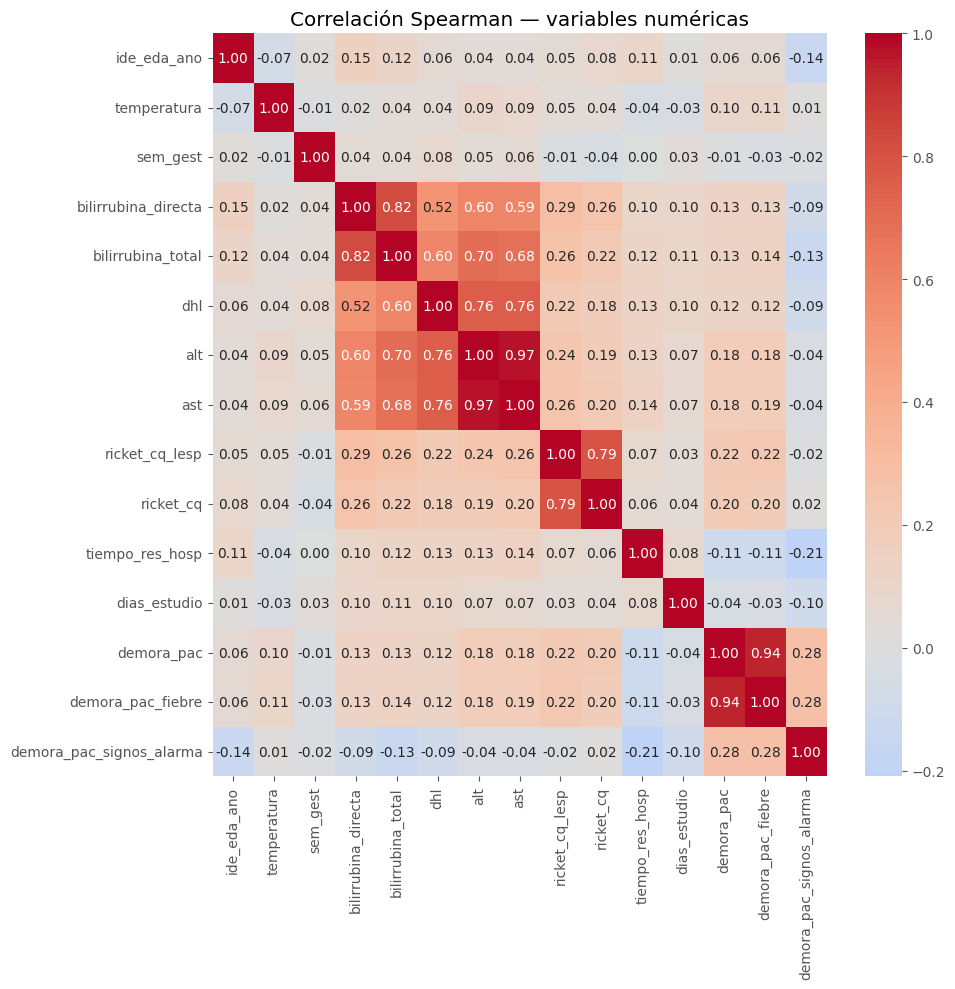

In [558]:
num_cols = rick.select_dtypes(include=['int', 'int64', 'float', 'float64']).columns

corr = rick[num_cols].corr(method='spearman') 

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlación Spearman — variables numéricas')
plt.tight_layout()
plt.show()

## **5. Análisis exploratorio**

### 5.1 Distribución geográfica

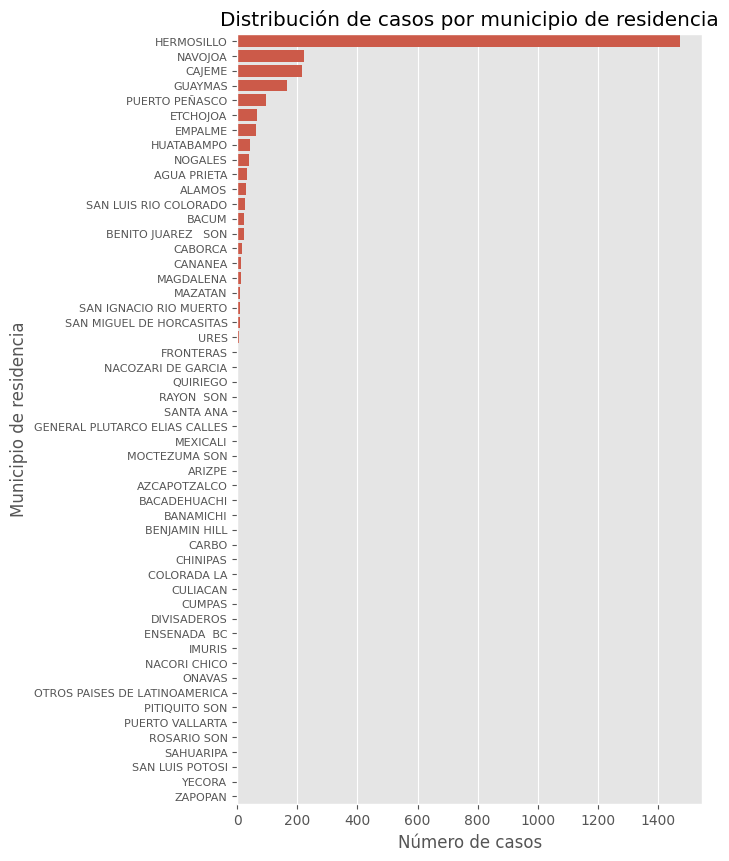

In [559]:
plt.figure(figsize=(6, 10))
sns.countplot(rick['des_mpo_res'], order=rick['des_mpo_res'].value_counts().index)
plt.title('Distribución de casos por municipio de residencia')
plt.ylabel('Municipio de residencia')
plt.xlabel('Número de casos')
plt.yticks(size = 8)
plt.show()

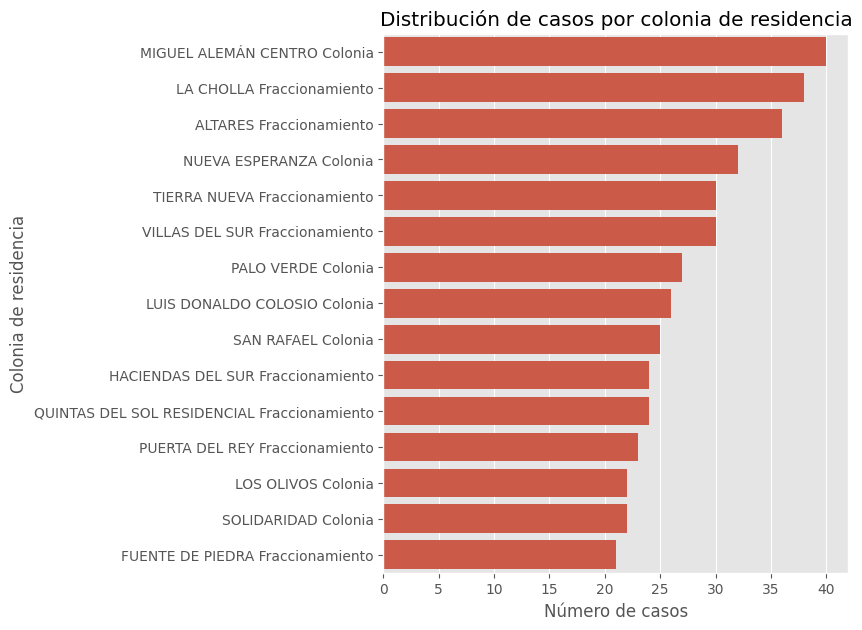

In [560]:
plt.figure(figsize=(6, 7))
sns.countplot(rick['ide_col'], order=rick['ide_col'].value_counts().head(15).index)
plt.title('Distribución de casos por colonia de residencia')
plt.ylabel('Colonia de residencia')
plt.xlabel('Número de casos')
plt.yticks(size = 10)
plt.show()

### 5.2 Edad y sexo

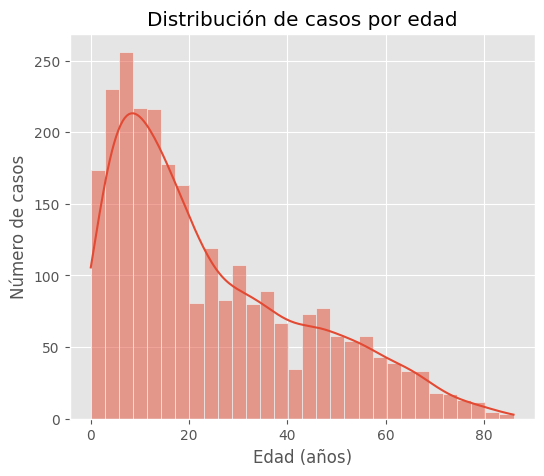

In [561]:
plt.figure(figsize=(6, 5))
sns.histplot(rick['ide_eda_ano'], bins=30, kde=True)
plt.title('Distribución de casos por edad')
plt.ylabel('Número de casos')
plt.xlabel('Edad (años)')
plt.show()

In [562]:
print(rick['ide_eda_ano'].describe())
print('--------------------')
print(f"\nMediana: {rick['ide_eda_ano'].median()}")
print(f"\nModa: {rick['ide_eda_ano'].mode().iloc[0]}")
print('--------------------')
print('\nEdades más frecuentes:')
rick['ide_eda_ano'].value_counts().head(15)

count   2631.00
mean      24.32
std       19.56
min        0.00
25%        8.00
50%       18.00
75%       37.00
max       86.00
Name: ide_eda_ano, dtype: float64
--------------------

Mediana: 18.0

Moda: 8
--------------------

Edades más frecuentes:


ide_eda_ano
8     93
5     91
9     85
7     84
14    83
6     79
4     78
11    73
15    71
1     71
12    67
13    66
3     61
16    60
10    59
Name: count, dtype: int64

C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\1452807955.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(rick['ide_sex'], palette = 'Accent')


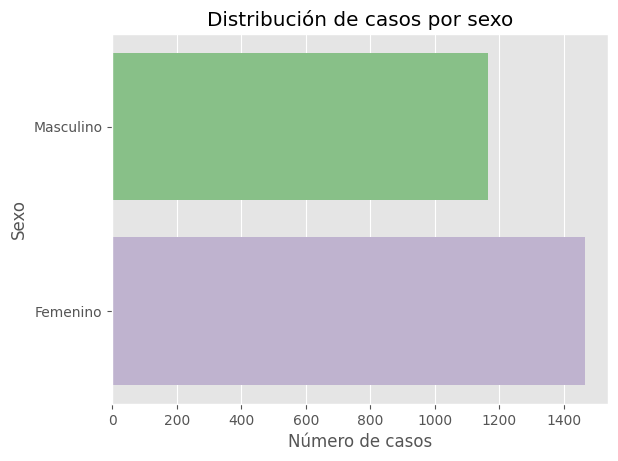

In [563]:
sns.countplot(rick['ide_sex'], palette = 'Accent')
plt.title('Distribución de casos por sexo')
plt.yticks(ticks = [0, 1], labels = ['Masculino', 'Femenino'])
plt.xlabel('Número de casos')
plt.ylabel('Sexo')
plt.show()

### 5.3 Variables clínicas

C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\1843302674.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(rick['estatus_caso'], palette='Set2')
C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\1843302674.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([mapeo_estatus_caso.get(int(t.get_text()), t.get_text())


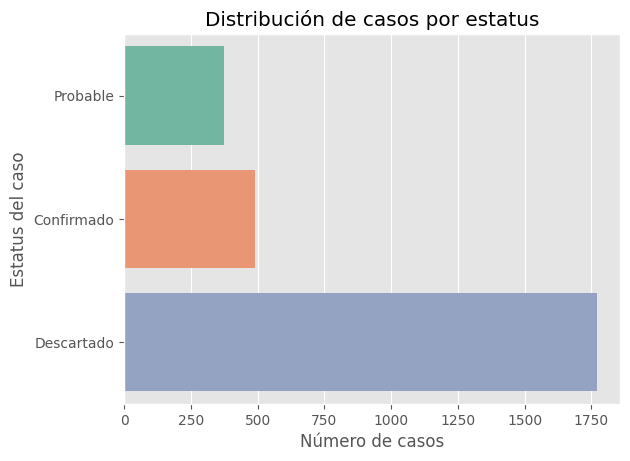

In [564]:
mapeo_estatus_caso = {1: 'Probable', 2: 'Confirmado', 3: 'Descartado'}

ax = sns.countplot(rick['estatus_caso'], palette='Set2')
ax.set_yticklabels([mapeo_estatus_caso.get(int(t.get_text()), t.get_text()) 
                    for t in ax.get_yticklabels()])
plt.title('Distribución de casos por estatus')
plt.ylabel('Estatus del caso')
plt.xlabel('Número de casos')
plt.show()

C:\Users\fanny\AppData\Local\Temp\ipykernel_14092\1332211908.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(rick['des_diag_final'], palette='Set2')


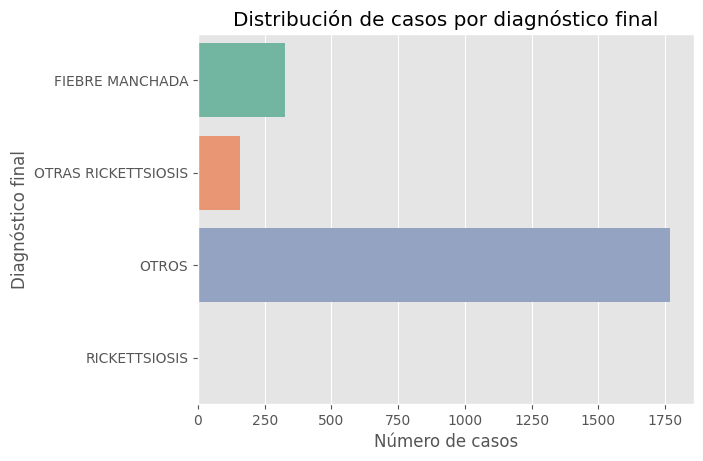

In [565]:
sns.countplot(rick['des_diag_final'], palette='Set2')
plt.title('Distribución de casos por diagnóstico final')
plt.ylabel('Diagnóstico final')
plt.xlabel('Número de casos')
plt.show()

count   2631.00
mean      38.61
std        0.82
min       28.00
25%       38.00
50%       39.00
75%       39.00
max       43.00
Name: temperatura, dtype: float64


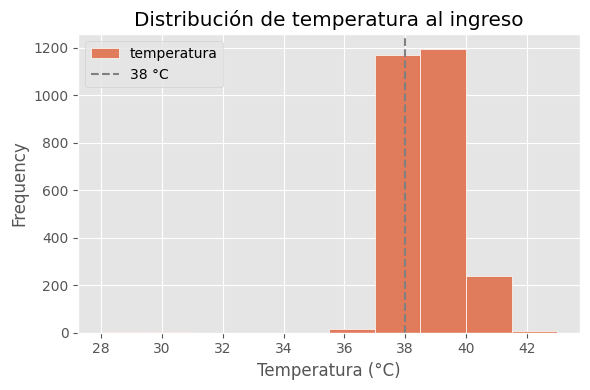

In [566]:
print(rick['temperatura'].describe())

fig, ax = plt.subplots(figsize=(6, 4))
rick['temperatura'].dropna().plot(kind='hist', bins=10, ax=ax,
    color='#E07B5C', edgecolor='white')
ax.axvline(38.0, color='gray', linestyle='--', label='38 °C')
ax.set_title('Distribución de temperatura al ingreso')
ax.set_xlabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Tiempo de respuesta

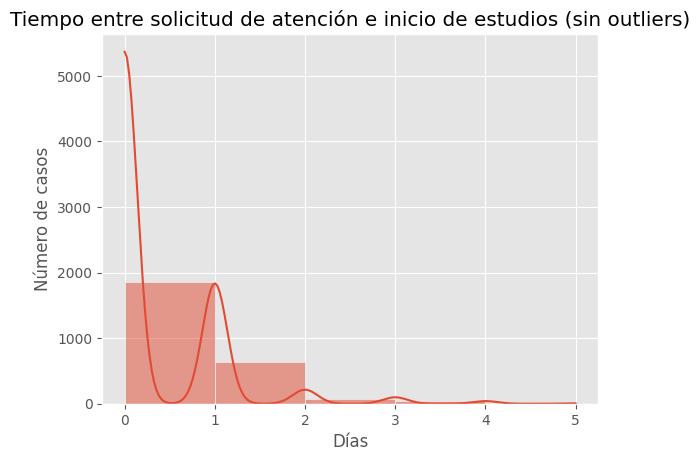

In [567]:
limite_inf = 0
limite_sup = 5

tiempo_res_sin_outliers = rick[(rick['tiempo_res_hosp'] >= limite_inf) & (rick['tiempo_res_hosp'] <= limite_sup)]


sns.histplot(tiempo_res_sin_outliers['tiempo_res_hosp'], bins=5, kde=True)
plt.title('Tiempo entre solicitud de atención e inicio de estudios (sin outliers)')
plt.xlabel('Días')
plt.ylabel('Número de casos')
plt.show()

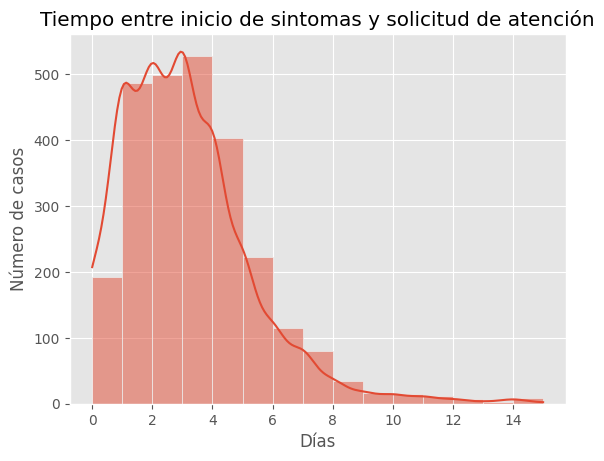

In [568]:
limite_inf = 0
limite_sup = 15 #Hasta un 15 días como máximo para filtrar outliers

demora_sin_outliers = rick[(rick['demora_pac'] >= limite_inf) & (rick['demora_pac'] <= limite_sup)]

sns.histplot(demora_sin_outliers['demora_pac'], bins=15, kde=True)
plt.title('Tiempo entre inicio de sintomas y solicitud de atención')
plt.xlabel('Días')
plt.ylabel('Número de casos')
plt.show()

#### 5.5 Series de tiempo

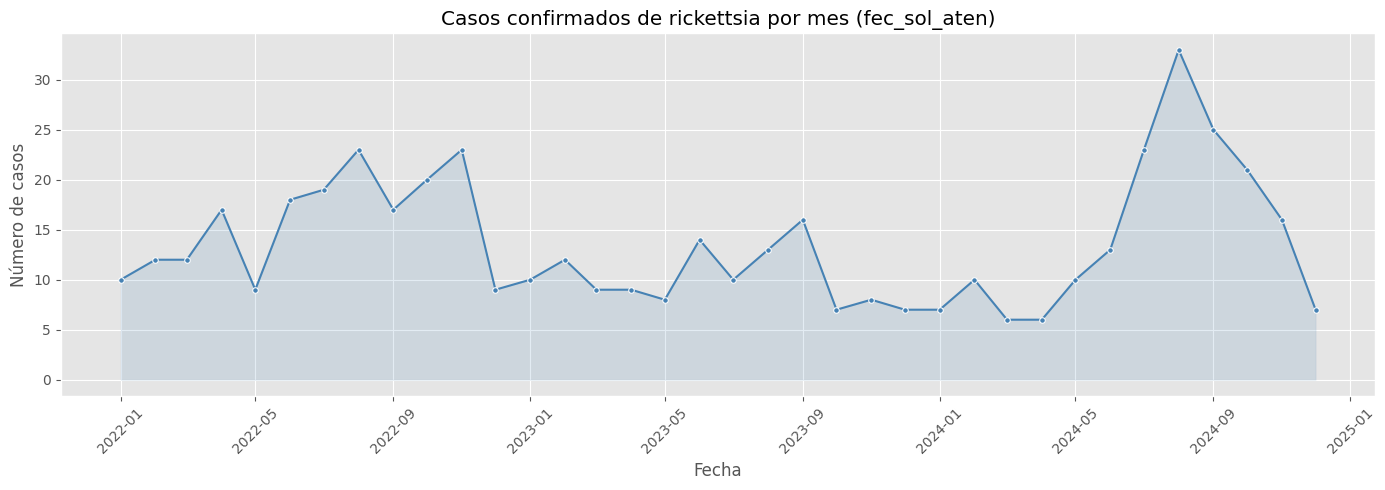

In [569]:
confirmados = rick[rick['estatus_caso'] == 2].copy()

confirmados_mes = (confirmados
                   .groupby(confirmados['fec_sol_aten'].dt.to_period('M'))
                   .size()
                   .reset_index(name='casos'))

confirmados_mes['fec_sol_aten'] = confirmados_mes['fec_sol_aten'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(data=confirmados_mes, x='fec_sol_aten', y='casos',
             color='steelblue', linewidth=1.5, marker='o', markersize=4, ax=ax)

ax.fill_between(confirmados_mes['fec_sol_aten'], confirmados_mes['casos'],
                alpha=0.15, color='steelblue')

ax.set_title('Casos confirmados de rickettsia por mes (fec_sol_aten)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de casos')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

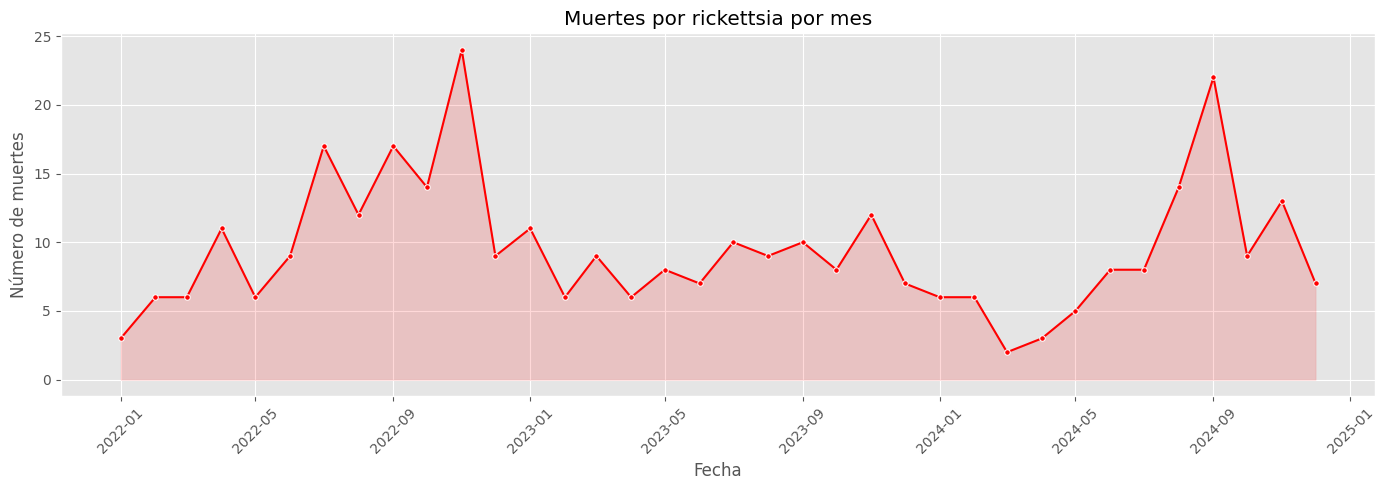

In [570]:
difuntos = rick[rick['cve_defuncion'] == 1].copy()

difuntos_mes = (difuntos
                   .groupby(difuntos['fec_defuncion'].dt.to_period('M'))
                   .size()
                   .reset_index(name='muertes'))

difuntos_mes['fec_defuncion'] = difuntos_mes['fec_defuncion'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(data=difuntos_mes, x='fec_defuncion', y='muertes',
             color='red', linewidth=1.5, marker='o', markersize=4, ax=ax)

ax.fill_between(difuntos_mes['fec_defuncion'], difuntos_mes['muertes'],
                alpha=0.15, color='red')

ax.set_title('Muertes por rickettsia por mes')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de muertes')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## **6. Exportación de datos limpios**

In [571]:
rick.to_csv('../data/interim/rick_eda_imput.csv', index = False)
rick.head(3)

,ide_id,ide_sex,ide_eda_ano,des_cal,ide_col,des_jur_res,des_mpo_res,cve_loc_res,des_loc_res,ide_cp,...,dias_estudio,demora_pac,demora_pac_fiebre,demora_pac_signos_alarma,fec_ini_estudio_corr,fec_fin_estudio_corr,fec_sol_aten_corr,fec_ini_signos_alarma_corr,fec_ini_signos_sint_corr,fec_ini_fiebre_corr
0,928424,1,39,CALLE,PASEOS DEL PEDREGAL Fraccionamiento,HERMOSILLO,HERMOSILLO,289,HERMOSILLO,83118.00,...,7.00,2,2.00,1.00,False,False,False,False,False,False
1,928745,2,8,CALLE,SAN RAFAEL Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83557.00,...,NaN,1,1.00,NaN,False,False,False,False,False,False
2,928768,2,2,CALLE,EL BOSQUE (CALLE QUINCE) Ejido,CAJEME,CAJEME,365,QUETCHEHUECA,85207.00,...,0.00,3,3.00,NaN,False,False,False,False,False,False


## **7. PCA**

In [572]:
print("\nVarianza de variables numéricas (top 20 por rango):")
display(rick.select_dtypes(include='number').describe().T
        .assign(rango=lambda x: x['max'] - x['min'])
        .sort_values('rango', ascending=False)
        .head(20)[['min', 'max', 'rango', 'mean', 'std']])


Varianza de variables numéricas (top 20 por rango):


,min,max,rango,mean,std
dhl,0.00,29928.00,29928.00,176.90,899.46
ast,0.00,9130.00,9130.00,63.51,377.31
alt,0.00,8748.00,8748.00,42.93,268.41
dias_estudio,0.00,196.00,196.00,5.76,10.27
tiempo_res_hosp,-3.00,118.00,121.00,0.46,2.94
ide_eda_ano,0.00,86.00,86.00,24.32,19.56
demora_pac,-4.00,63.00,67.00,3.12,2.71
demora_pac_fiebre,-3.00,63.00,66.00,2.91,2.74
ricket_cq,0.00,40.29,40.29,4.50,11.54
ricket_cq_lesp,0.00,39.04,39.04,6.02,12.66


- **'dhl' - Resultados de Deshidrogenasa Láctica**  - es una enzima citoplasmática presente en casi todos los tejidos del cuerpo. Debido a su amplia distribución, sus niveles en sangre son un marcador muy sensible pero poco específico de daño celular.

        - Rango médico posible: 0 a >20,000 Unidades/Litro en casos extremos

Por lo tanto, se decide no eliminar el valor extremo de los datos. 
- **'ast' - Resultados de Aspartato aminotransferasa**  - es una enzima que se encuentra en diversos tejidos, principalmente en el corazón, el hígado y los músculos. Al igual que la LDH, es un marcador de lesión celular, aunque su rango de variación es distinto.

        - Rango médico posible: 7 a >400 Unidades/Litro en casos extremos
Gravedad acorde a rango:

        - Leve: 40-120 U/L
        - Moderada: 120-400 U/L
        - Grave: >400 U/L

Por lo tanto, se decide no eliminar los valores extremos de los datos        
- **'alt' - Resultados de Aspartato aminotransferasa**  - es una enzima que se encuentra principalmente en el hígado. Funciona como un marcador de salud hepática

        - Rango médico posible: ~7 a >750 Unidades/Litro en casos extremos
Gravedad acorde a rango:

        - Leve: 55-250 U/L
        - Moderada: 250-750 U/L
        - Grave: >750 U/L

Por lo tanto, se decide no eliminar los valores extremos de los datos 

Como variable objetivo utilizaremos 'estatus_caso' donde:
- 1: Caso probable
- 2: Caso confirmado
- 3: Caso descartado

In [573]:
TARGET = 'estatus_caso'

# Verificar distribución del target
print("Distribución del target:")
print(rick[TARGET].value_counts(dropna=False))


Distribución del target:
estatus_caso
3    1769
2     489
1     373
Name: count, dtype: int64


Para diagnostico utilizaremos:
- Variables demográficas y epidemiológicas
- Signos y síntomas clínicos — evaluables en consulta
- Comorbilidades

Excluiremos variables de laboratorio, ya que no están disponibles al momento del diagnóstico inicial y podrían introducir sesgo de información. Así como variables que indiquen el diagnóstico de rickettsia y variables indicadoras de ubicación geográfica.

In [574]:
# Excluir columnas no útiles para el PCA 

# Por tipo
fechas = rick.select_dtypes(include='datetime').columns.tolist()

identificadores = ['ide_id', 'ide_cp', 'cve_loc_res', 'ide_col', 'des_jur_res', 'des_mpo_res', 'des_loc_res', 
                   'lengua_indigena', 'des_cual_lengua', 'des_ocupacion', 'des_cal']
columnas_texto = ['otro_sintoma', 'otros_especifique', 'otro_sintoma_binario']
indicadores = []
diagnosticos = []
procesos = ['manejo', 'evolucion', 'otr_serv_atencion', 'servic_atencion']
unidades_medicas = []
tratamiento = ['tratamiento_rickettsiosis', 'med_trat_ricket']
laboratorios = ['ricket_cq_lesp', 'ricket_cq', 'liquido_cavidad_toracica', 'liquido_cavidad_abdominal', 'lcr', 
                'compromiso_organos', 'compromiso_organos_binario', 'dhl', 'alt', 'ast', 'ast_alt', 'bilirrubina_total', 'bilirrubina_directa',
                'muestra_laboratorio', 'rickett_resultado_ser1', 'ricket_especie_rtpcr', 'res_final_ricket_rtpcr', 'res_final_ricket_inmuno', 
                'rickett_resultado_ser1', 'mstra_rech_ricket_sangre', 'motiv_rech_ricket_sangre', 'dismin_plaquetas', 'dismin_hemoglob',
                'aumento_hematocrito', 'escape_plasma']
indicadores_defun = ['cve_defuncion', 'cve_egreso']
indicadores_rick = ['estatus_caso']
tiempos = ['tiempo_res_hosp', 'dias_estudio', 'demora_pac', 'demora_pac_fiebre', 'demora_pac_signos_alarma']
vars_otras_enfermedades = [
    'changoma',
    'signo_romana',
    'mmegacolon',
    'mmegaesofago',
    'cardiopatia_dilatada',
    'miocardiopatia'
]

for col in rick.columns:
    if col.lower().endswith('_corr'):
        indicadores.append(col)
    if col.lower().endswith('_imput'):
        indicadores.append(col)
    if 'diag' in col.lower():
        diagnosticos.append(col)
    if 'uni' in col.lower():
        unidades_medicas.append(col)

excluir_diag = list(set(identificadores +fechas + indicadores + diagnosticos + procesos + unidades_medicas + tratamiento + laboratorios \
                   + indicadores_defun + indicadores_rick + tiempos + columnas_texto + vars_otras_enfermedades))
cols_pca = [c for c in rick.columns if c not in excluir_diag]

print(f"Variables candidatas para PCA: {len(cols_pca)}")
print(cols_pca)

Variables candidatas para PCA: 96
['ide_sex', 'ide_eda_ano', 'es_indigena', 'contacto_garrapata', 'contacto_otr', 'agua_potable', 'eliminacion_basura', 'temperatura', 'cefalea', 'mialgias', 'artralgias', 'poliartralgias', 'artritis', 'dolor_retroocular', 'exantema', 'nauseas', 'vomito', 'petequias', 'torniquete_positivo', 'vomito_persistentes', 'dolor_abdominal_intenso', 'acumulacion_liquidos', 'sangrado_mucosas', 'letargo', 'irritabilidad', 'hipotension_postural', 'hepatomegalia', 'taquicardia', 'extremidades_frias', 'llenado_capilar', 'presion_convergente', 'hipotension_arterial', 'insuficiencia_respiratoria', 'hematemesis', 'melena', 'metrorragia_voluminosa', 'sangrado_snc', 'alteraciones_conciencias', 'miocarditis', 'dolor_espalda', 'prurito', 'diaforesis', 'escalofrios', 'fotofobia', 'lipotimia', 'diarrea', 'conjuntivitis', 'congestion_nasal', 'tos', 'faringitis', 'esplenomegalia', 'alteraciones_gusto', 'adenomegalias', 'disnea', 'alteraciones_cardiacas', 'nodulos', 'ulceras', 'le

In [575]:
rick[cols_pca].isna().sum().sort_values(ascending=False).head(15)

ide_sex               0
ide_eda_ano           0
es_indigena           0
contacto_garrapata    0
contacto_otr          0
agua_potable          0
eliminacion_basura    0
temperatura           0
cefalea               0
mialgias              0
artralgias            0
poliartralgias        0
artritis              0
dolor_retroocular     0
exantema              0
dtype: int64

### Preparación de datos para PCA

In [576]:
# Clasificación de tipo de feature
df_resumen = pd.DataFrame({
    'tipo_dato': rick[cols_pca].dtypes,
    'valores_unicos': rick[cols_pca].nunique()
})
pd.set_option('display.max_rows', None)
print(df_resumen)

                           tipo_dato  valores_unicos
ide_sex                     category               2
ide_eda_ano                    int64              86
es_indigena                 category               2
contacto_garrapata          category               2
contacto_otr                category              16
agua_potable                category               3
eliminacion_basura          category               3
temperatura                  float64              11
cefalea                     category               3
mialgias                    category               3
artralgias                  category               3
poliartralgias              category               3
artritis                    category               3
dolor_retroocular           category               3
exantema                    category               3
nauseas                     category               3
vomito                      category               3
petequias                   category          

In [577]:
# Porcentaje de datos no válidos (valor 0, donde 1= Si y 2 = No)
porcentaje_ignora = (rick[cols_pca] == 0).mean() * 100
print(porcentaje_ignora.sort_values(ascending=False))

cirrosis_hepatica            99.85
enf_ulcero_peptica           99.77
inmunosupresion              99.62
enf_renal                    99.43
embarazo                     99.01
sem_gest                     99.01
trans_hemorr                 98.06
hipertension                 95.82
diabetes                     94.60
contacto_garrapata            7.22
miocarditis                   3.80
llenado_capilar               3.72
hematemesis                   3.72
metrorragia_voluminosa        3.72
extremidades_frias            3.72
presion_convergente           3.72
sangrado_snc                  3.72
melena                        3.72
alteraciones_conciencias      3.72
hipotension_arterial          3.69
insuficiencia_respiratoria    3.65
taquicardia                   3.65
eliminacion_basura            3.34
hematomas                     2.77
agua_potable                  2.74
hepatomegalia                 2.58
hipotension_postural          2.43
derrame_pleural               2.39
irritabilidad       

Se revisa cuántas variables que deberían ser binarias, incluyen el valor '0' para indicar un valor nulo o otros valores. 

In [578]:
reporte_listado = []

for col in cols_pca:
    # Obtenemos la cantidad de valores únicos
    n_unicos = rick[col].nunique()
    
    # Verificamos si es tipo 'category' y si tiene más de 2 valores
    es_categoria = str(rick[col].dtype) == 'category'
    
    if n_unicos > 2 and es_categoria:
        # Calculamos el porcentaje de ceros (datos no válidos)
        pct_cero = (rick[col] == 0).mean() * 100
        
        # Agregamos al listado de reporte
        reporte_listado.append({
            'Variable': col,
            'Porcentaje_No_Valido (0)': pct_cero,
            'Valores_Unicos': n_unicos,
            'Tipo': rick[col].dtype
        })

df_reporte_calidad = pd.DataFrame(reporte_listado)

if not df_reporte_calidad.empty:
    print("Variables categóricas con más de 2 valores únicos y su porcentaje de datos no válidos (0):")
    print(df_reporte_calidad.sort_values(by='Porcentaje_No_Valido (0)', ascending=False).to_string(index=False))

Variables categóricas con más de 2 valores únicos y su porcentaje de datos no válidos (0):
                  Variable  Porcentaje_No_Valido (0)  Valores_Unicos     Tipo
               miocarditis                      3.80               3 category
           llenado_capilar                      3.72               3 category
              sangrado_snc                      3.72               3 category
                    melena                      3.72               3 category
    metrorragia_voluminosa                      3.72               3 category
               hematemesis                      3.72               3 category
       presion_convergente                      3.72               3 category
        extremidades_frias                      3.72               3 category
  alteraciones_conciencias                      3.72               3 category
      hipotension_arterial                      3.69               3 category
insuficiencia_respiratoria                      3.6

Las variables categóricas, al contar con un bajo porcentaje de 'Se ignora', los consideraremos en la categoría de 'No'. Donde:
0: Se ignora, 1: Sí, 2: No

In [579]:
var_bin = df_reporte_calidad[df_reporte_calidad['Porcentaje_No_Valido (0)'] < 5]['Variable'].tolist()
multi = {'des_cal', 'contacto_otr'}
var_bin = [x for x in var_bin if x not in multi]

# Mostramos el resultado
print(f"Se encontraron {len(var_bin)} variables con <5% ceros:")
print(var_bin)

Se encontraron 81 variables con <5% ceros:
['agua_potable', 'eliminacion_basura', 'cefalea', 'mialgias', 'artralgias', 'poliartralgias', 'artritis', 'dolor_retroocular', 'exantema', 'nauseas', 'vomito', 'petequias', 'torniquete_positivo', 'vomito_persistentes', 'dolor_abdominal_intenso', 'acumulacion_liquidos', 'sangrado_mucosas', 'letargo', 'irritabilidad', 'hipotension_postural', 'hepatomegalia', 'taquicardia', 'extremidades_frias', 'llenado_capilar', 'presion_convergente', 'hipotension_arterial', 'insuficiencia_respiratoria', 'hematemesis', 'melena', 'metrorragia_voluminosa', 'sangrado_snc', 'alteraciones_conciencias', 'miocarditis', 'dolor_espalda', 'prurito', 'diaforesis', 'escalofrios', 'fotofobia', 'lipotimia', 'diarrea', 'conjuntivitis', 'congestion_nasal', 'tos', 'faringitis', 'esplenomegalia', 'alteraciones_gusto', 'adenomegalias', 'disnea', 'alteraciones_cardiacas', 'nodulos', 'ulceras', 'lesion_membranas', 'ictericia', 'desorientacion', 'convulsiones', 'debilidad_muscular',

In [580]:
rick_pca = rick[cols_pca].copy()

for var in var_bin:
    #Filtramos la columna para ignorar temporalmente los ceros
    valores_sin_cero = rick_pca[var][rick_pca[var] != 0]
    
    # Calculamos la moda de los valores no cero
    if not valores_sin_cero.empty:
        moda_filtrada = valores_sin_cero.mode()[0]
        
        # Reemplazamos los ceros por esa moda real
        rick_pca[var] = rick_pca[var].replace(0, moda_filtrada)
    else:
        print(f"Advertencia: La variable '{var}' solo contiene ceros. No se pudo calcular la moda.")

Revisamos que todas las variables categóricas ahora sean binarias:

In [581]:
# Clasificación de tipo de feature
df_resumen = pd.DataFrame({
    'tipo_dato': rick_pca[cols_pca].dtypes,
    'valores_unicos': rick_pca[cols_pca].nunique()
})
pd.set_option('display.max_rows', None)
print(df_resumen)
pd.reset_option('display.max_rows')

                           tipo_dato  valores_unicos
ide_sex                     category               2
ide_eda_ano                    int64              86
es_indigena                 category               2
contacto_garrapata          category               2
contacto_otr                category              16
agua_potable                category               2
eliminacion_basura          category               2
temperatura                  float64              11
cefalea                     category               2
mialgias                    category               2
artralgias                  category               2
poliartralgias              category               2
artritis                    category               2
dolor_retroocular           category               2
exantema                    category               2
nauseas                     category               2
vomito                      category               2
petequias                   category          

#### Manejo de variables con múltiples categorías

In [582]:
#rick_pca= pd.get_dummies(rick_pca[cols_pca], columns=['contacto_otr'], drop_first=True)

#Conversión a binaria: (por desbalance de categorías, descarte one hot encoding)
# Crea la columna asignando 1 a lo diferente de 'Sin contacto' y 0 a lo que sea igual
rick_pca['contacto_otr_bin'] = (rick_pca['contacto_otr'] != 'Sin contacto').astype(int)
rick_pca = rick_pca.drop(columns=['contacto_otr'])

rick_pca['estatus_caso'] = rick['estatus_caso']
rick_pca.head()

,ide_sex,ide_eda_ano,es_indigena,contacto_garrapata,agua_potable,eliminacion_basura,temperatura,cefalea,mialgias,artralgias,...,diabetes,hipertension,enf_ulcero_peptica,enf_renal,inmunosupresion,cirrosis_hepatica,embarazo,sem_gest,contacto_otr_bin,estatus_caso
0,1,39,2,1,2,2,39.00,2,1,2,...,0,0,0,0,0,0,0,0,0,2
1,2,8,2,1,1,2,39.00,1,1,2,...,0,0,0,0,0,0,0,0,0,3
2,2,2,2,0,1,1,39.00,1,1,1,...,0,0,0,0,0,0,0,0,0,1
3,1,9,2,1,1,1,39.00,1,1,1,...,0,0,0,0,0,0,0,0,0,3
4,2,13,2,1,1,1,39.00,1,1,1,...,0,0,0,0,0,0,0,0,0,2


#### Checkpoint - exportación de dataset para PCA

In [591]:
rick_pca.to_csv('../data/interim/rick_pca.csv', index=False)

#### Estandarización

In [584]:
X = rick_pca.drop(columns=[TARGET])
y = rick[TARGET]

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Ejecución de PCA**

In [585]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Dataframe con resultados
df_pca = pd.DataFrame(data = X_pca)

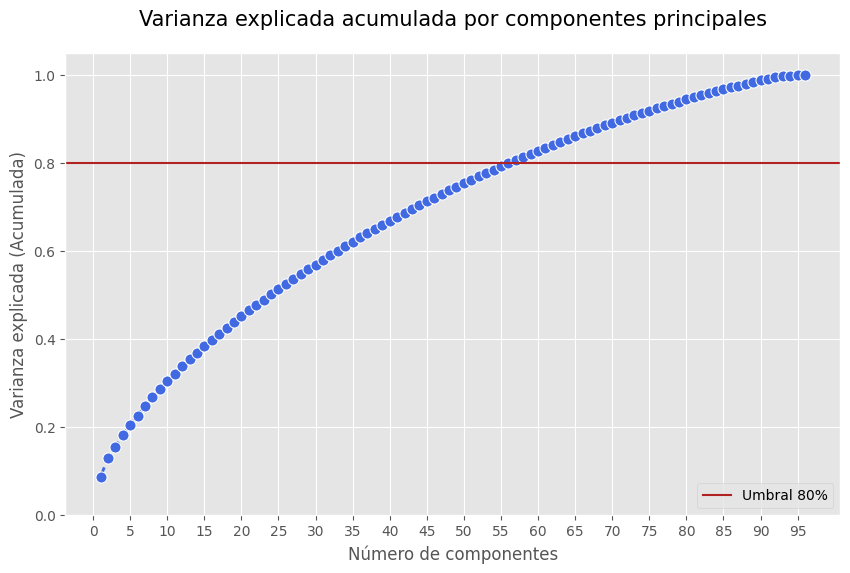

In [586]:
# Grafica de varianza explicada acumulada

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
componentes = range(1, len(varianza_acumulada) + 1)

df_scree = pd.DataFrame({
    'Número de componentes': componentes,
    'Varianza explicada': varianza_acumulada
})


plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_scree, 
    x='Número de componentes', 
    y='Varianza explicada', 
    marker='o', 
    markersize=8,
    linestyle='--',
    linewidth=2,
    color='royalblue' 
)

plt.axhline(y=0.80, color='firebrick', linestyle='-', label='Umbral 80%')

plt.title('Varianza explicada acumulada por componentes principales', fontsize=15, pad=20)
plt.xlabel('Número de componentes', fontsize=12)
plt.ylabel('Varianza explicada (Acumulada)', fontsize=12)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')

if len(componentes) > 20:
    plt.xticks(np.arange(0, len(componentes) + 1, step=5))

plt.show()

In [587]:
individual_var = pca.explained_variance_ratio_[:15] * 100
cumulative_var = np.cumsum(pca.explained_variance_ratio_[:15]) * 100

reporte_varianza = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(individual_var))],
    'Varianza Individual (%)': individual_var,
    'Varianza Acumulada (%)': cumulative_var
})

pd.options.display.float_format = '{:.2f}'.format

print("Varianza explicada por los primeros 15 componentes principales:")
print(reporte_varianza.to_string(index=False))

total_15 = cumulative_var[-1]
print(f"\nTotal explicado por los primeros 15 componentes: {total_15:.2f}%")

Varianza explicada por los primeros 15 componentes principales:
Componente  Varianza Individual (%)  Varianza Acumulada (%)
       PC1                     8.70                    8.70
       PC2                     4.29                   12.99
       PC3                     2.61                   15.60
       PC4                     2.54                   18.14
       PC5                     2.31                   20.45
       PC6                     2.21                   22.66
       PC7                     2.15                   24.81
       PC8                     2.00                   26.81
       PC9                     1.83                   28.65
      PC10                     1.77                   30.42
      PC11                     1.75                   32.17
      PC12                     1.68                   33.85
      PC13                     1.61                   35.46
      PC14                     1.49                   36.95
      PC15                     1.48 

In [588]:
# Variables principales del primer componente (PC1)

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(X.columns))], index=X.columns)
print("Top variables en PC1:")
print(loadings['PC1'].sort_values(ascending=False).head(15))

Top variables en PC1:
alteraciones_cardiacas       0.23
alteraciones_neurologicas    0.23
extremidades_frias           0.22
choque                       0.22
alteraciones_conciencias     0.22
taquicardia                  0.22
llenado_capilar              0.21
insuficiencia_respiratoria   0.21
letargo                      0.20
desorientacion               0.19
disnea                       0.18
hipotension_arterial         0.17
somolencia                   0.15
fatiga                       0.15
equimosis                    0.15
Name: PC1, dtype: float64


In [589]:
# Variables principales del primer componente (PC2)

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(X.columns))], index=X.columns)
print("Top variables en PC2:")
print(loadings['PC2'].sort_values(ascending=False).head(15))

Top variables en PC2:
fotofobia            0.27
dolor_espalda        0.27
alteraciones_gusto   0.26
conjuntivitis        0.23
escalofrios          0.22
fatiga               0.21
faringitis           0.18
otitis               0.18
adinamia             0.17
prurito              0.17
congestion_nasal     0.16
tos                  0.16
dolor_retroocular    0.15
artritis             0.15
astenia              0.15
Name: PC2, dtype: float64


In [590]:
# Variables principales del primer componente (PC3)

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(X.columns))], index=X.columns)
print("Top variables en PC3:")
print(loadings['PC3'].sort_values(ascending=False).head(15))

Top variables en PC3:
ide_eda_ano          0.34
diabetes             0.25
ulceras              0.23
nodulos              0.23
hipertension         0.20
paralisis            0.18
linfadenopatia       0.17
hiperemia_faringea   0.17
signos_meningeos     0.17
faringitis           0.17
adenomegalias        0.17
exantema             0.16
lesion_membranas     0.15
trans_hemorr         0.14
congestion_nasal     0.11
Name: PC3, dtype: float64


Dados los resultados del análisis PCA, podemos observar que los síntomas relacionados al corazón son los que explican la mayor varianza en el componente principal 1, sin embargo, se esperaría ver una varianza acumulada en los primeros componentes mayor a la que se obtuvo, esto podría indicar que los datos están poco relacionados, tienen mucho ruído, o hay un desbalance grave de categorías. 

**Acorde a revisión con médico**: Es coherente, ya que está describiendo la cascada fisiopatológica de la rickettsiosis grave de forma coherente. Rickettsia invade el endotelio vascular, genera vasculitis sistémica, que produce hipoperfusión, que lleva a falla multiorgánica.

El PC2 muestra un cuadro de síntomas de vasculitis sistémica: inflamación de los vasos sanguíneos pequeños.

**Acorde a revisión con médico**: Los síntomas de dolor en la espalda, conjuntivitis, fatiga y astenia, son síntomas poco comúnes pero presentes en la fiebre manchada (Rickettsiosis). El resto parece ser relacionado a dengue u otras infecciones virales. 

Como se discutió con el médico, algunas de las variables de PC2 pueden usarse como discriminantes para rechazar diagnóstico de Rickettsiosis. El PC2 caracteriza al paciente que con cuadro leve o atípico.

Finalmente, el PC3 indica perfil de riesgo demográfico y comorbilidad, parece predecir letalidad de forma independiente a PC1 — Un paciente mayor diabético hipertenso puede llegar con cuadro aparentemente leve (PC2 alto, PC1 bajo) pero PC3 alto ya señala que tiene alto riesgo de deterioro rápido.
La edad como variable dominante en PC3 es consistente con la literatura — en Sonora los casos fatales tienen edad promedio significativamente mayor que los sobrevivientes.